# Final Regime Distribution Engine
**Core Definitions:**
* **Regime Model:** SuperTrend (ATR Trailing Stop) - Pure binary trend classification.
* **Target Duration (T):** 13 Days
* **Return Window (T / 3):** ~4 Days
* **Lookback:** 26 Days

This clean master file finalizes the Regime Classification step. It takes a massive block of data, mathematically identifies the UP and DOWN regimes using SuperTrend, and outputs the return distribution histograms and statistical classifications for BOTH regimes.


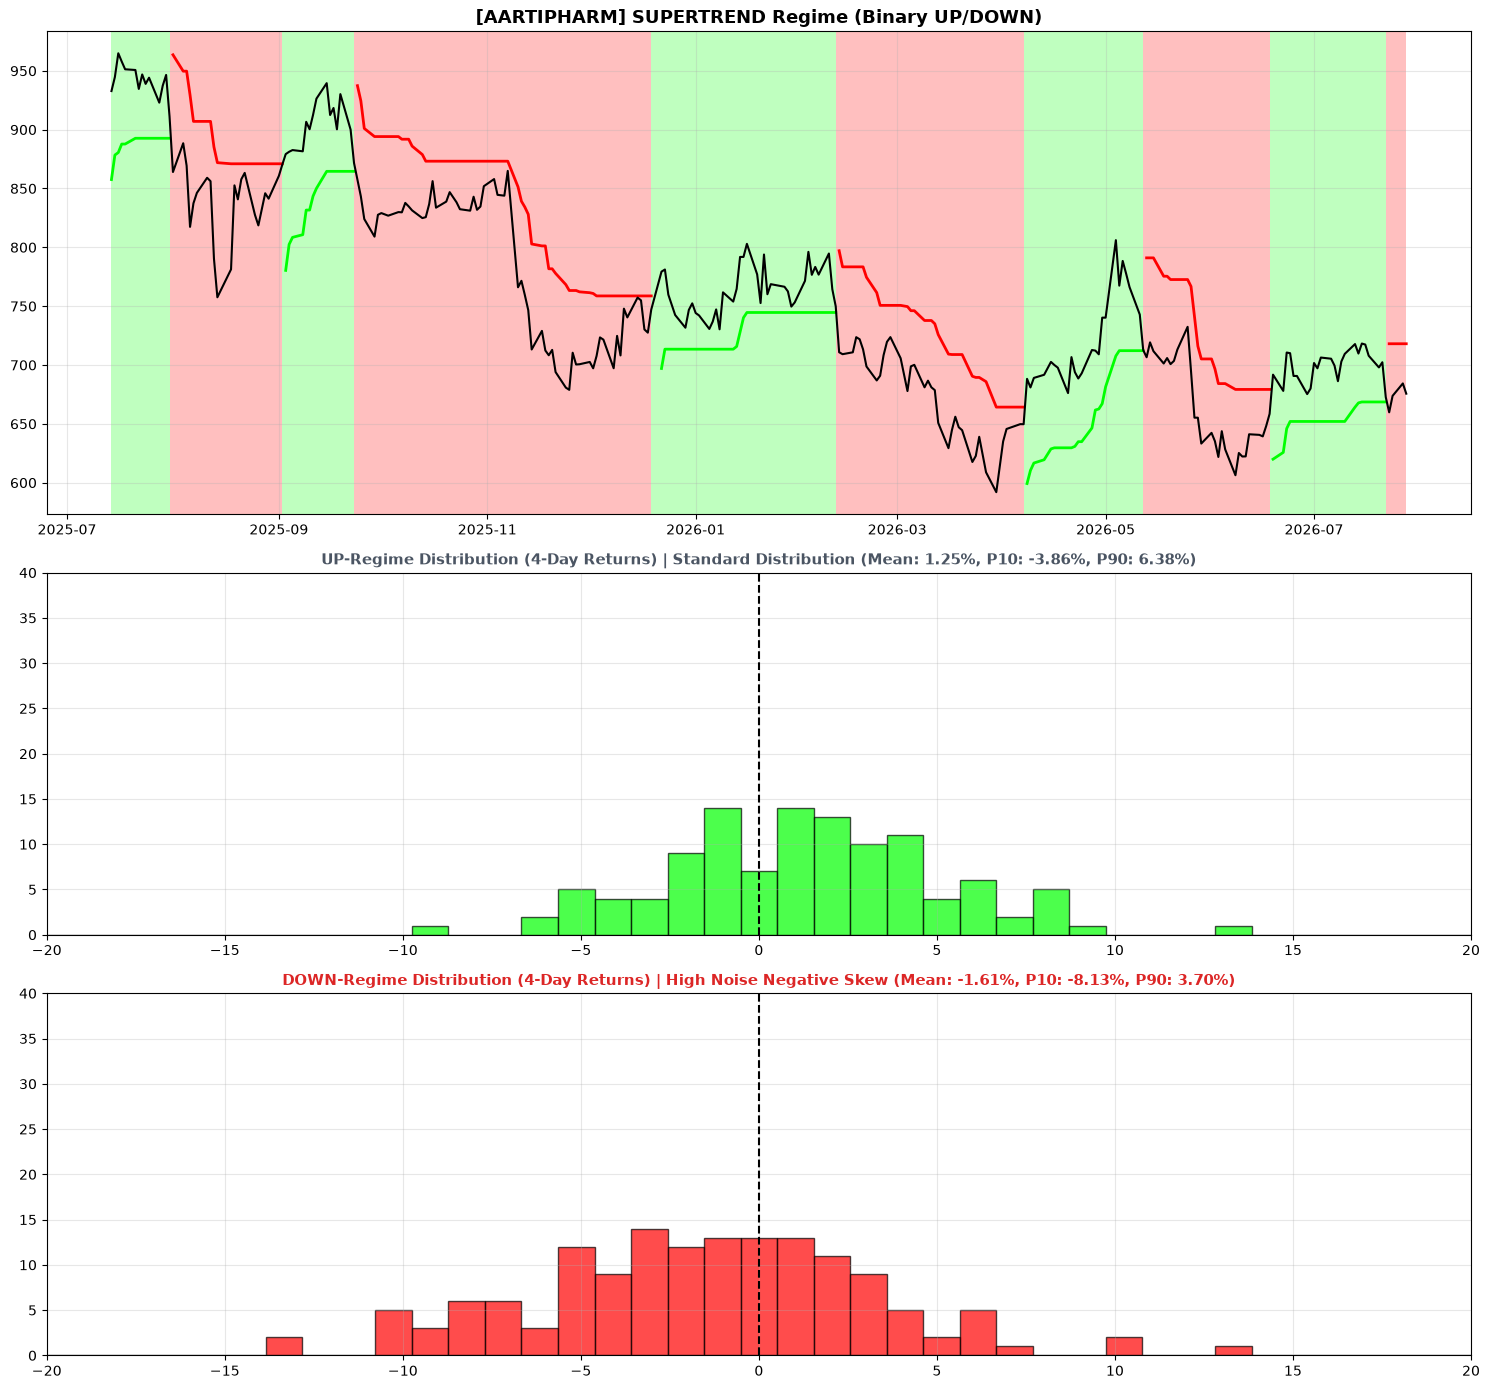

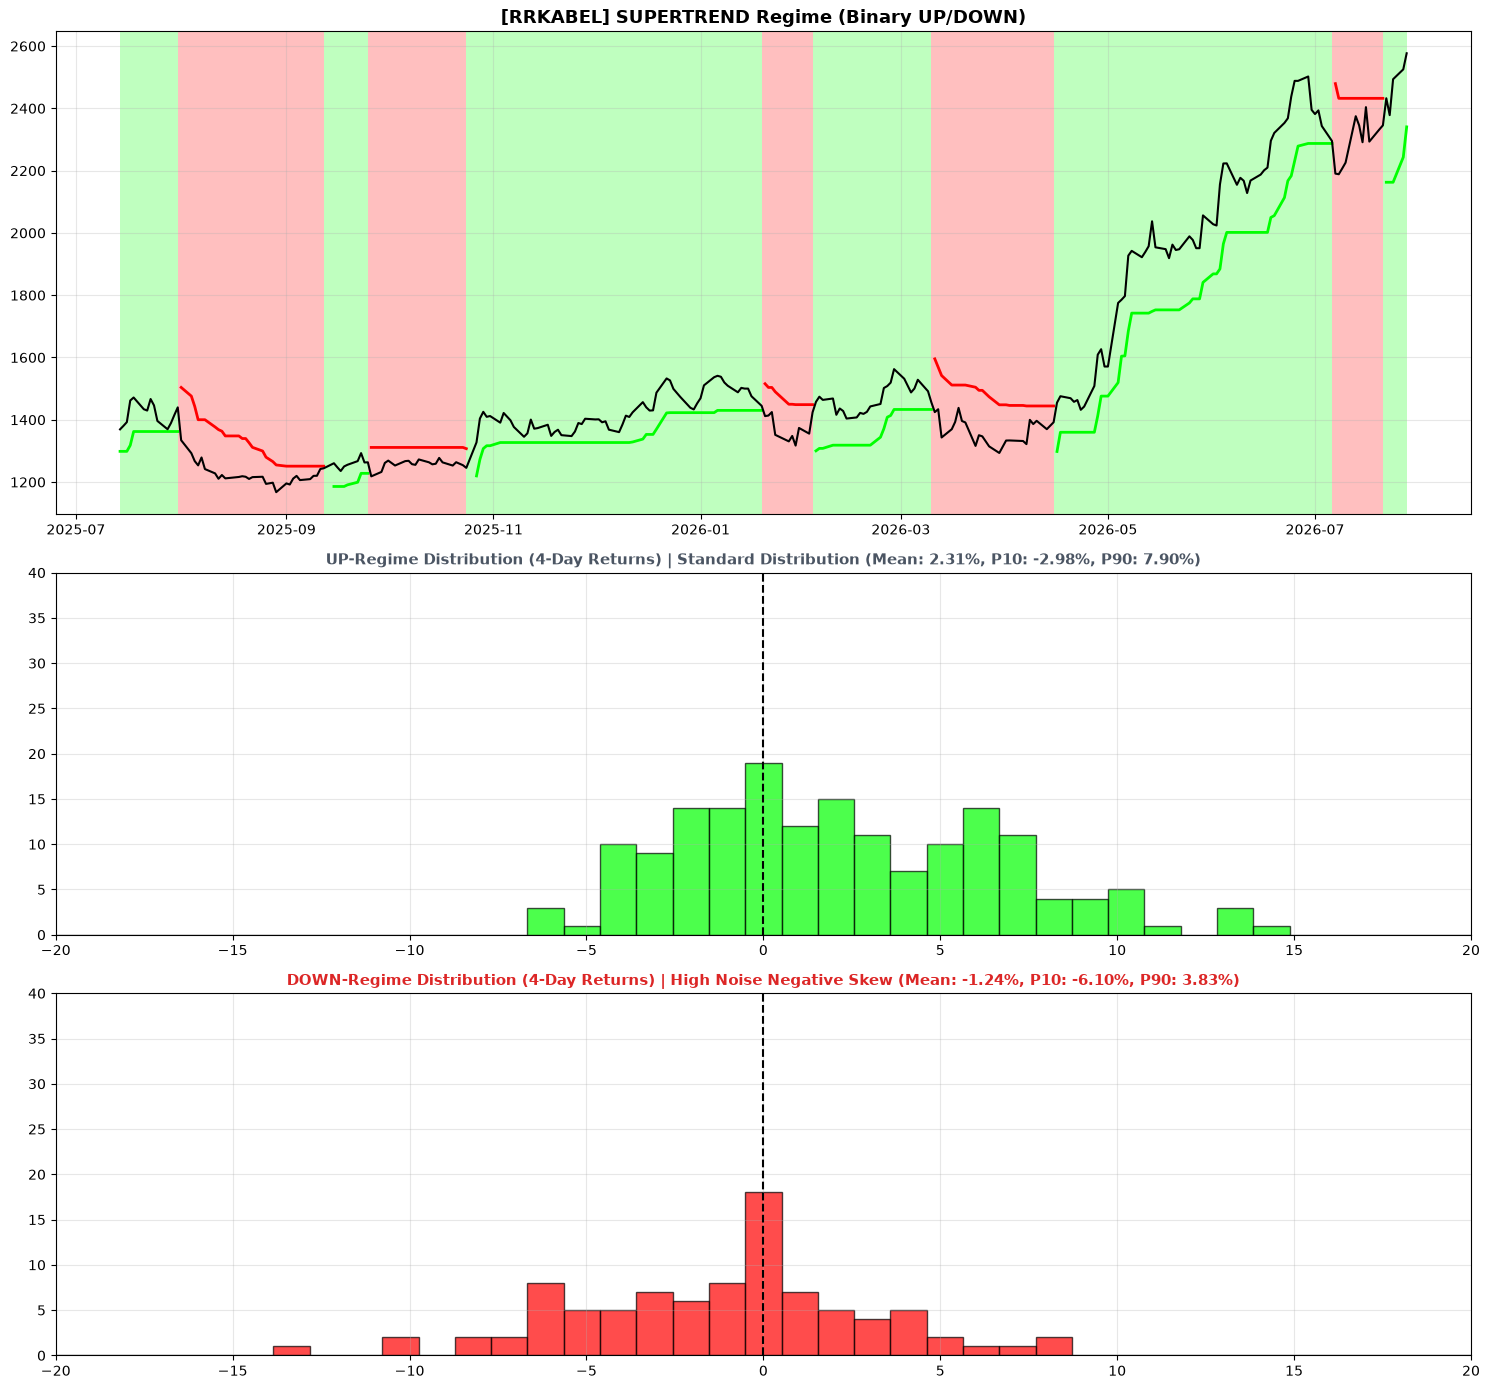

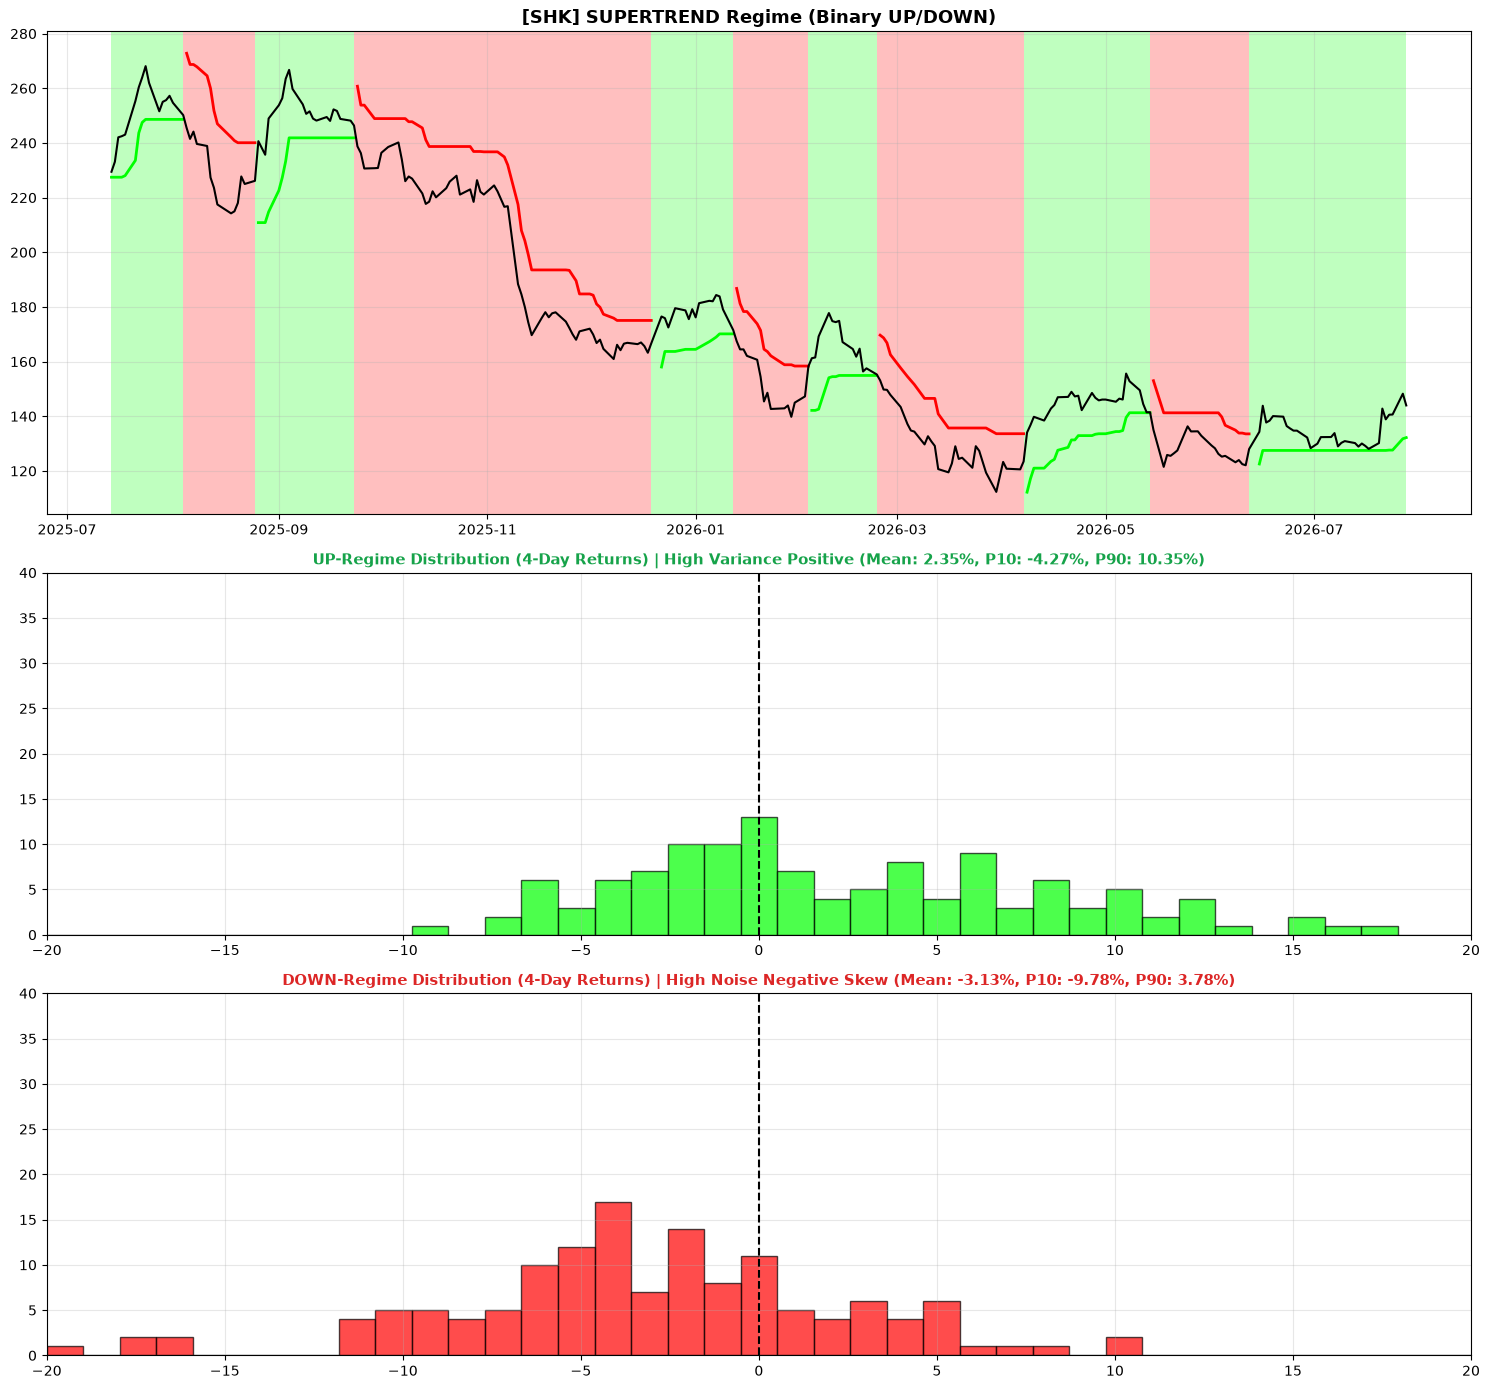

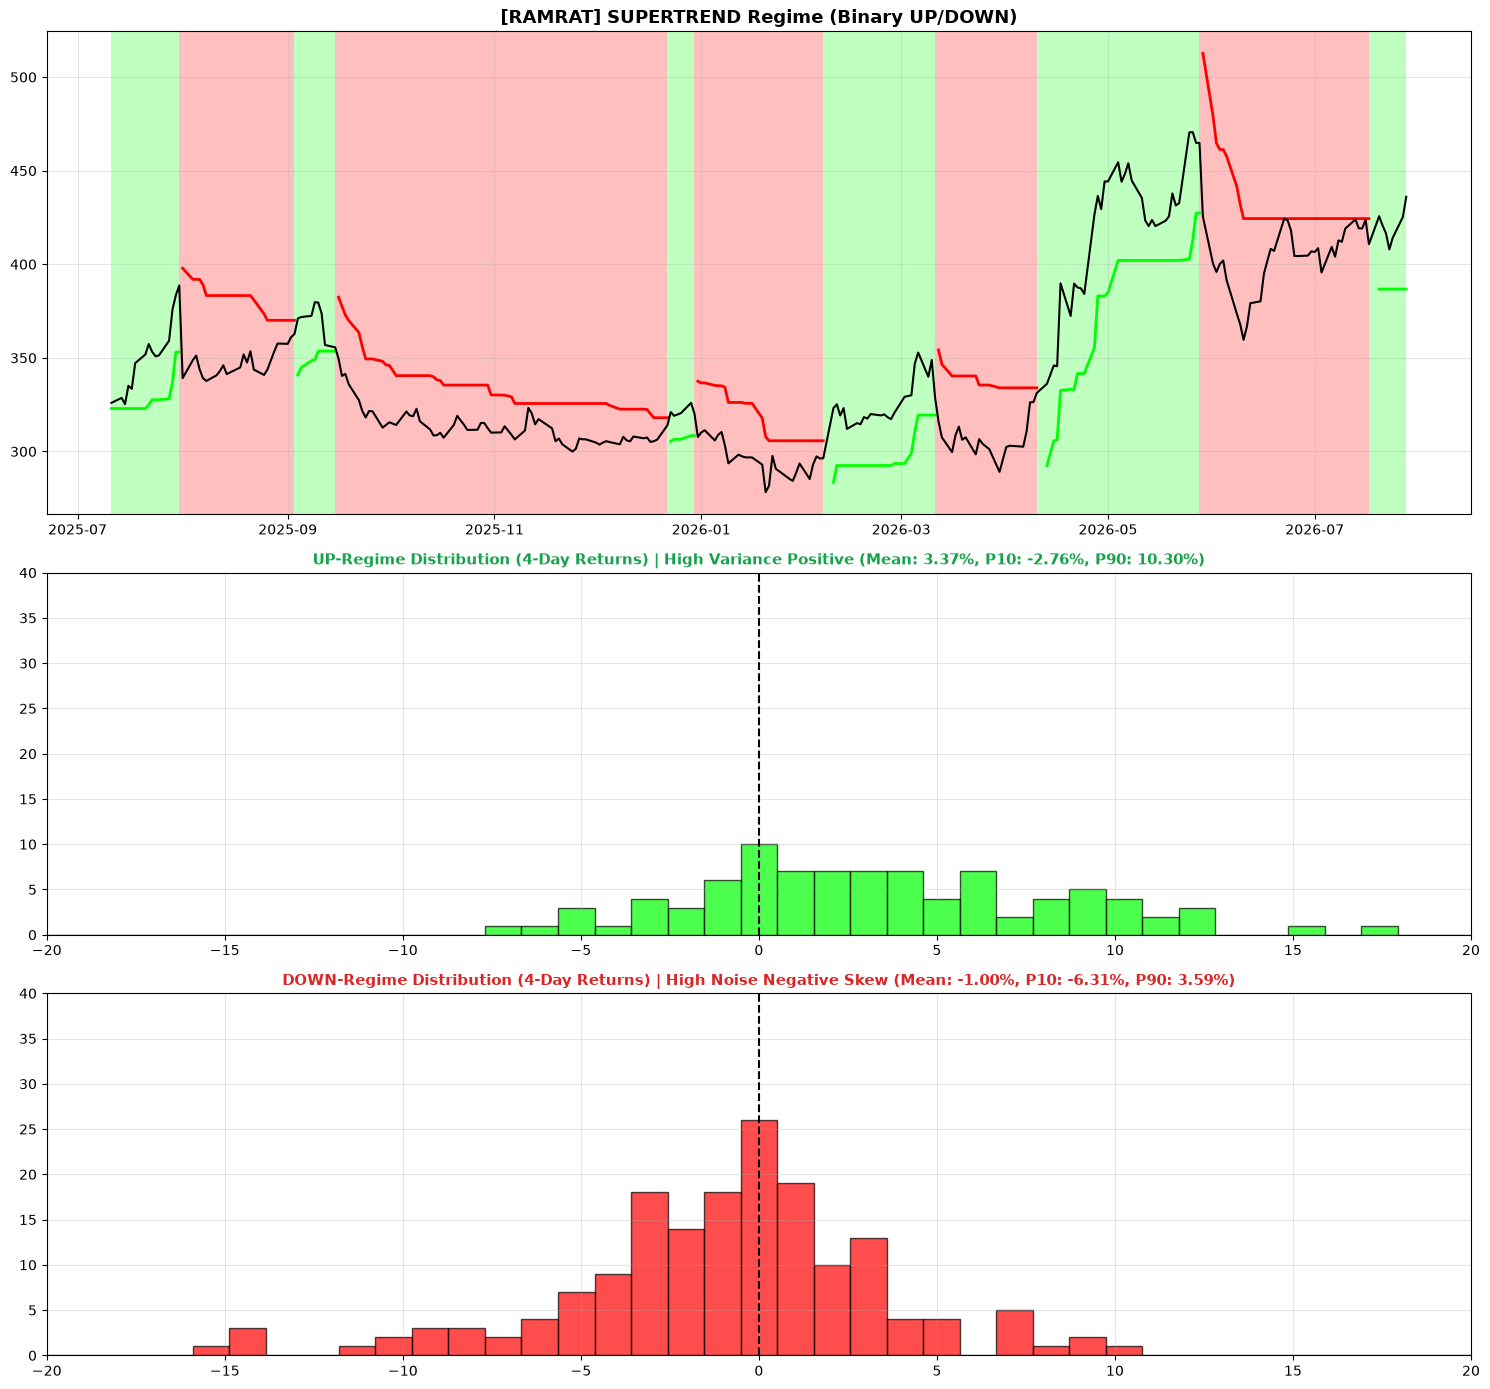

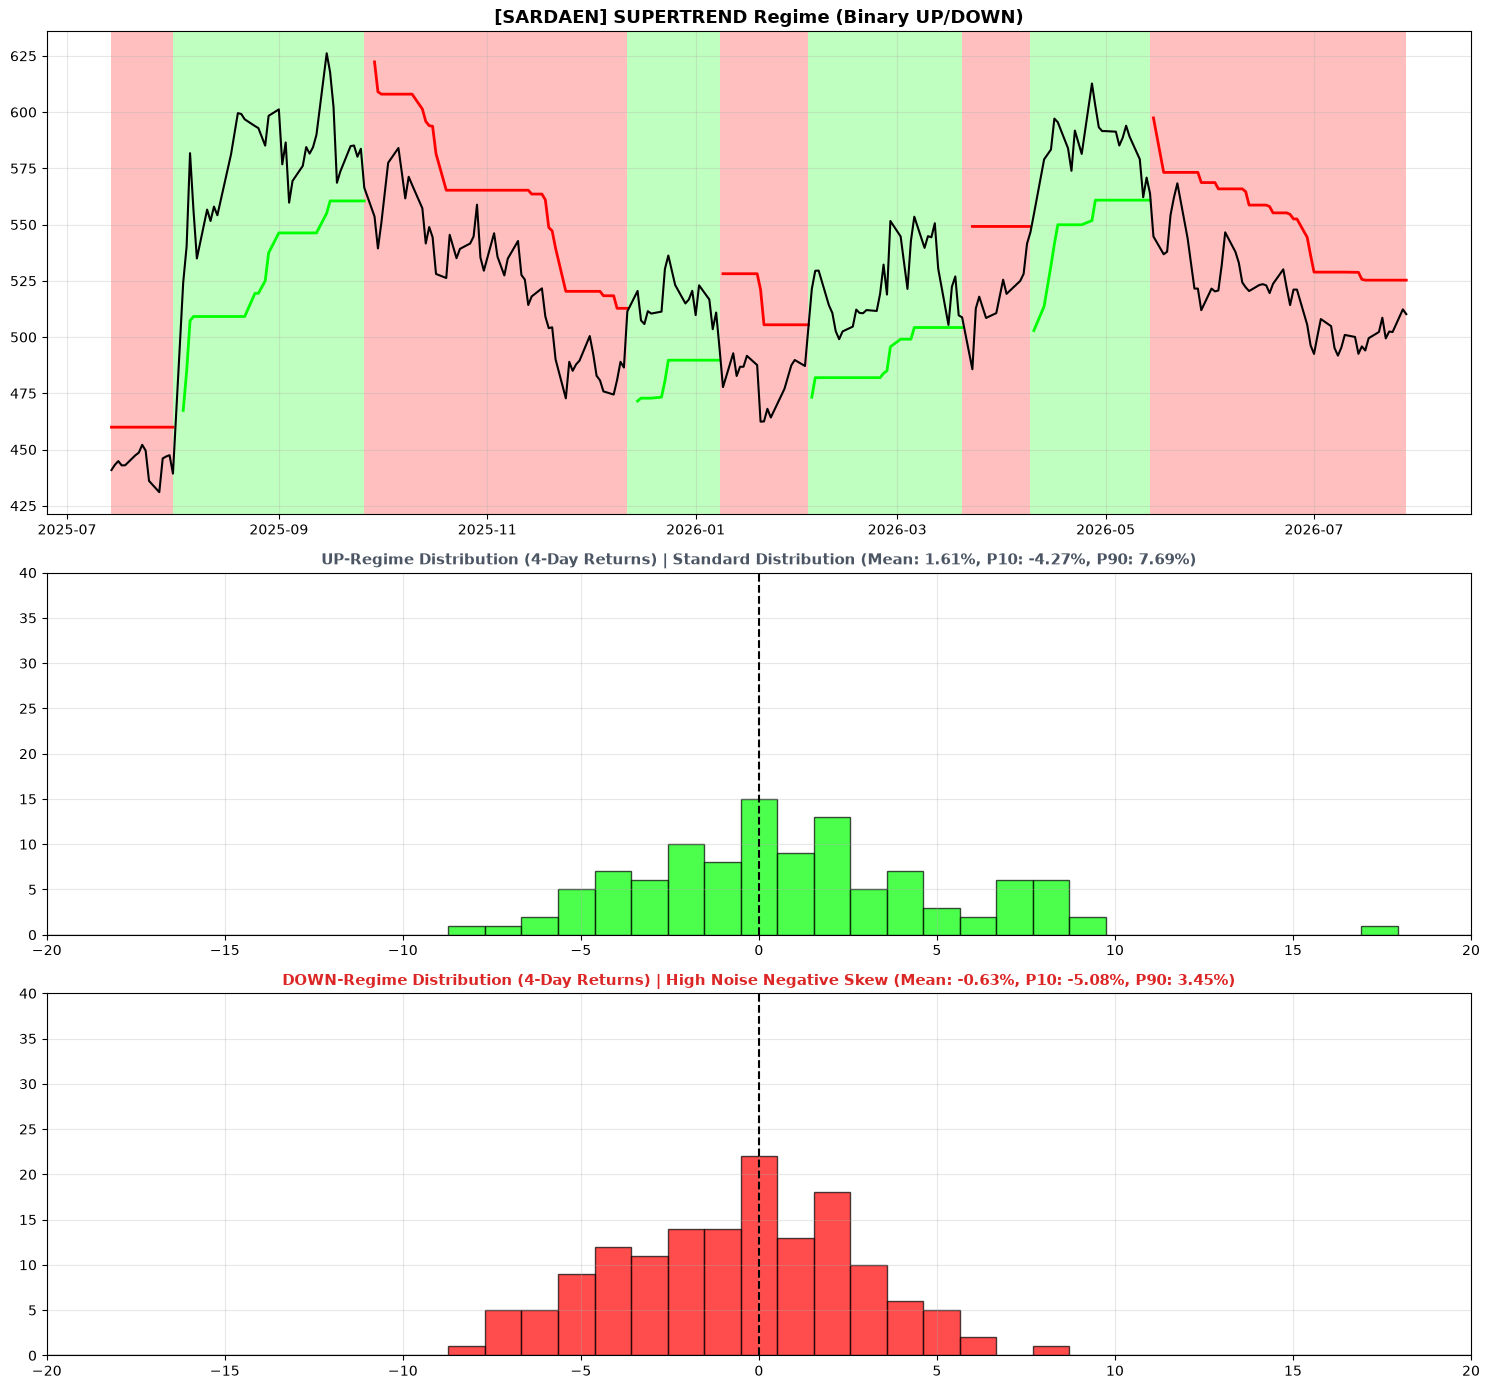

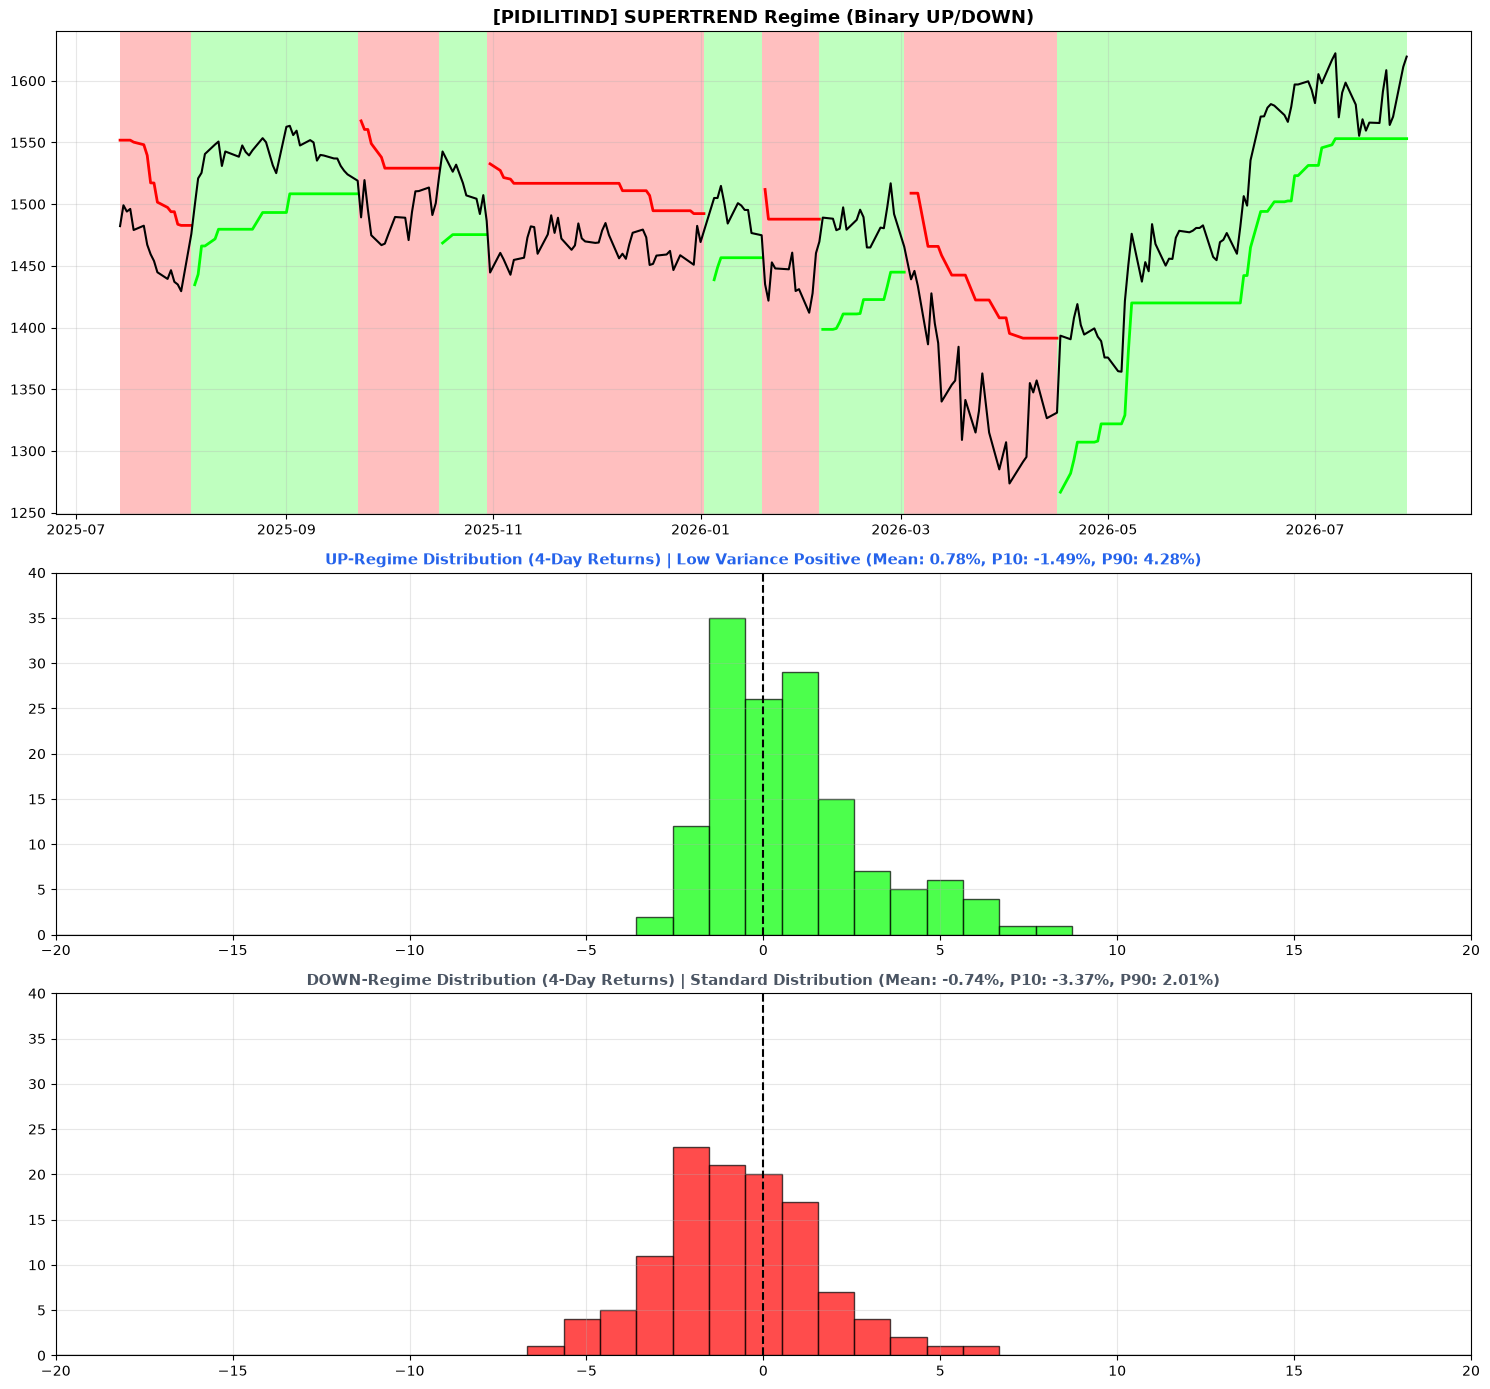

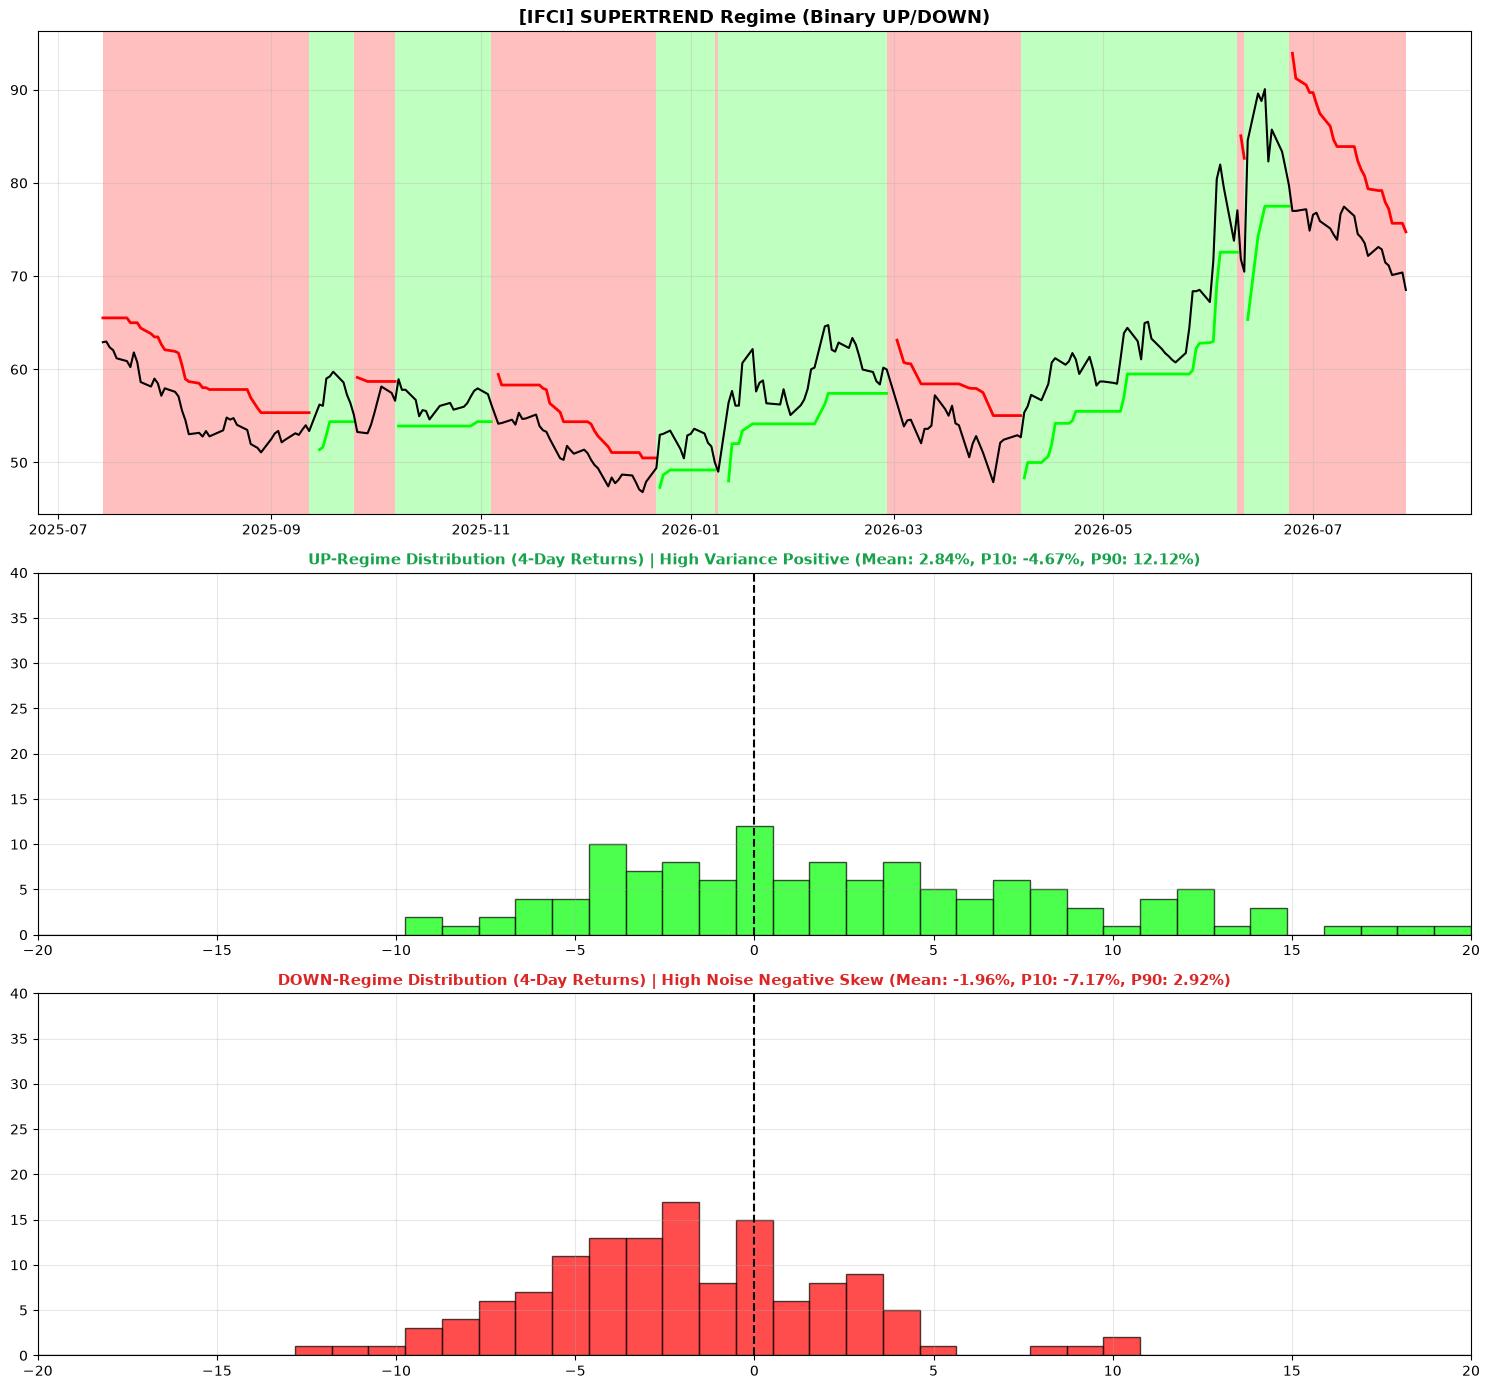

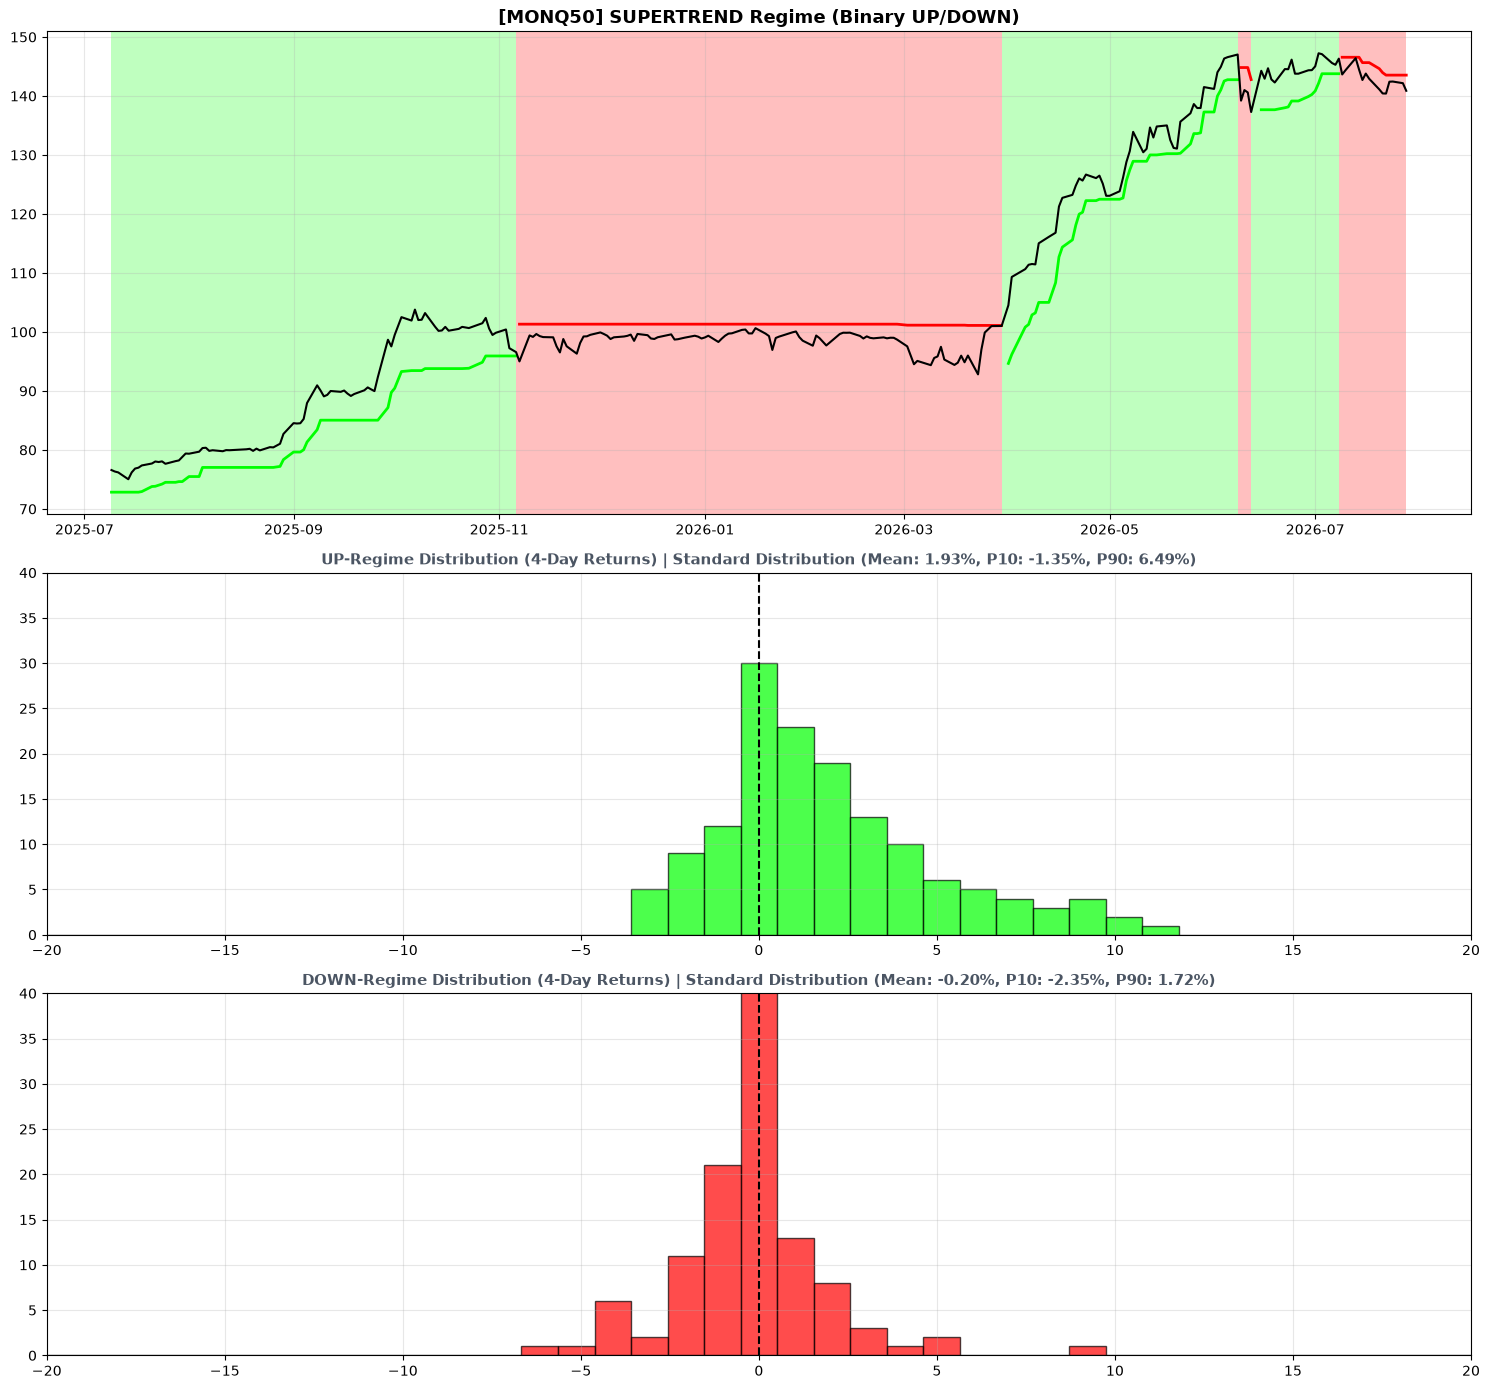

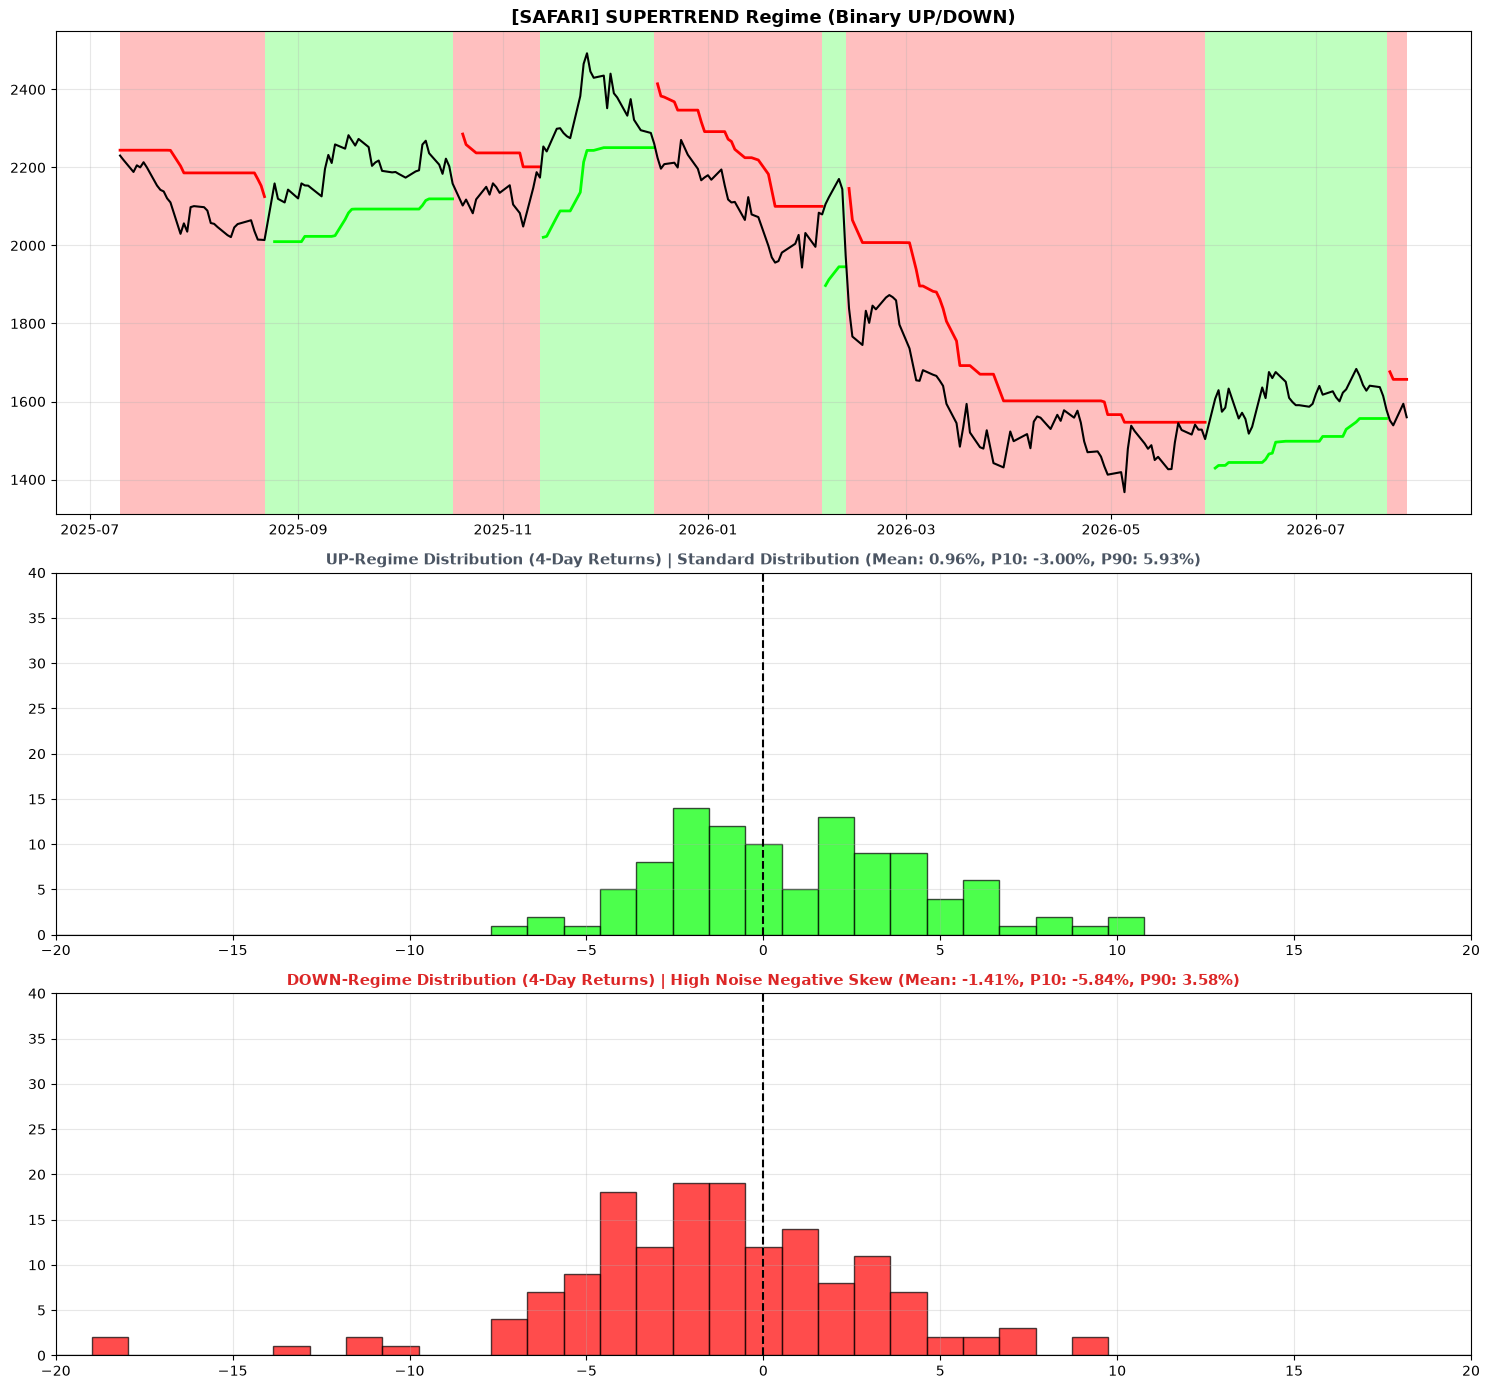

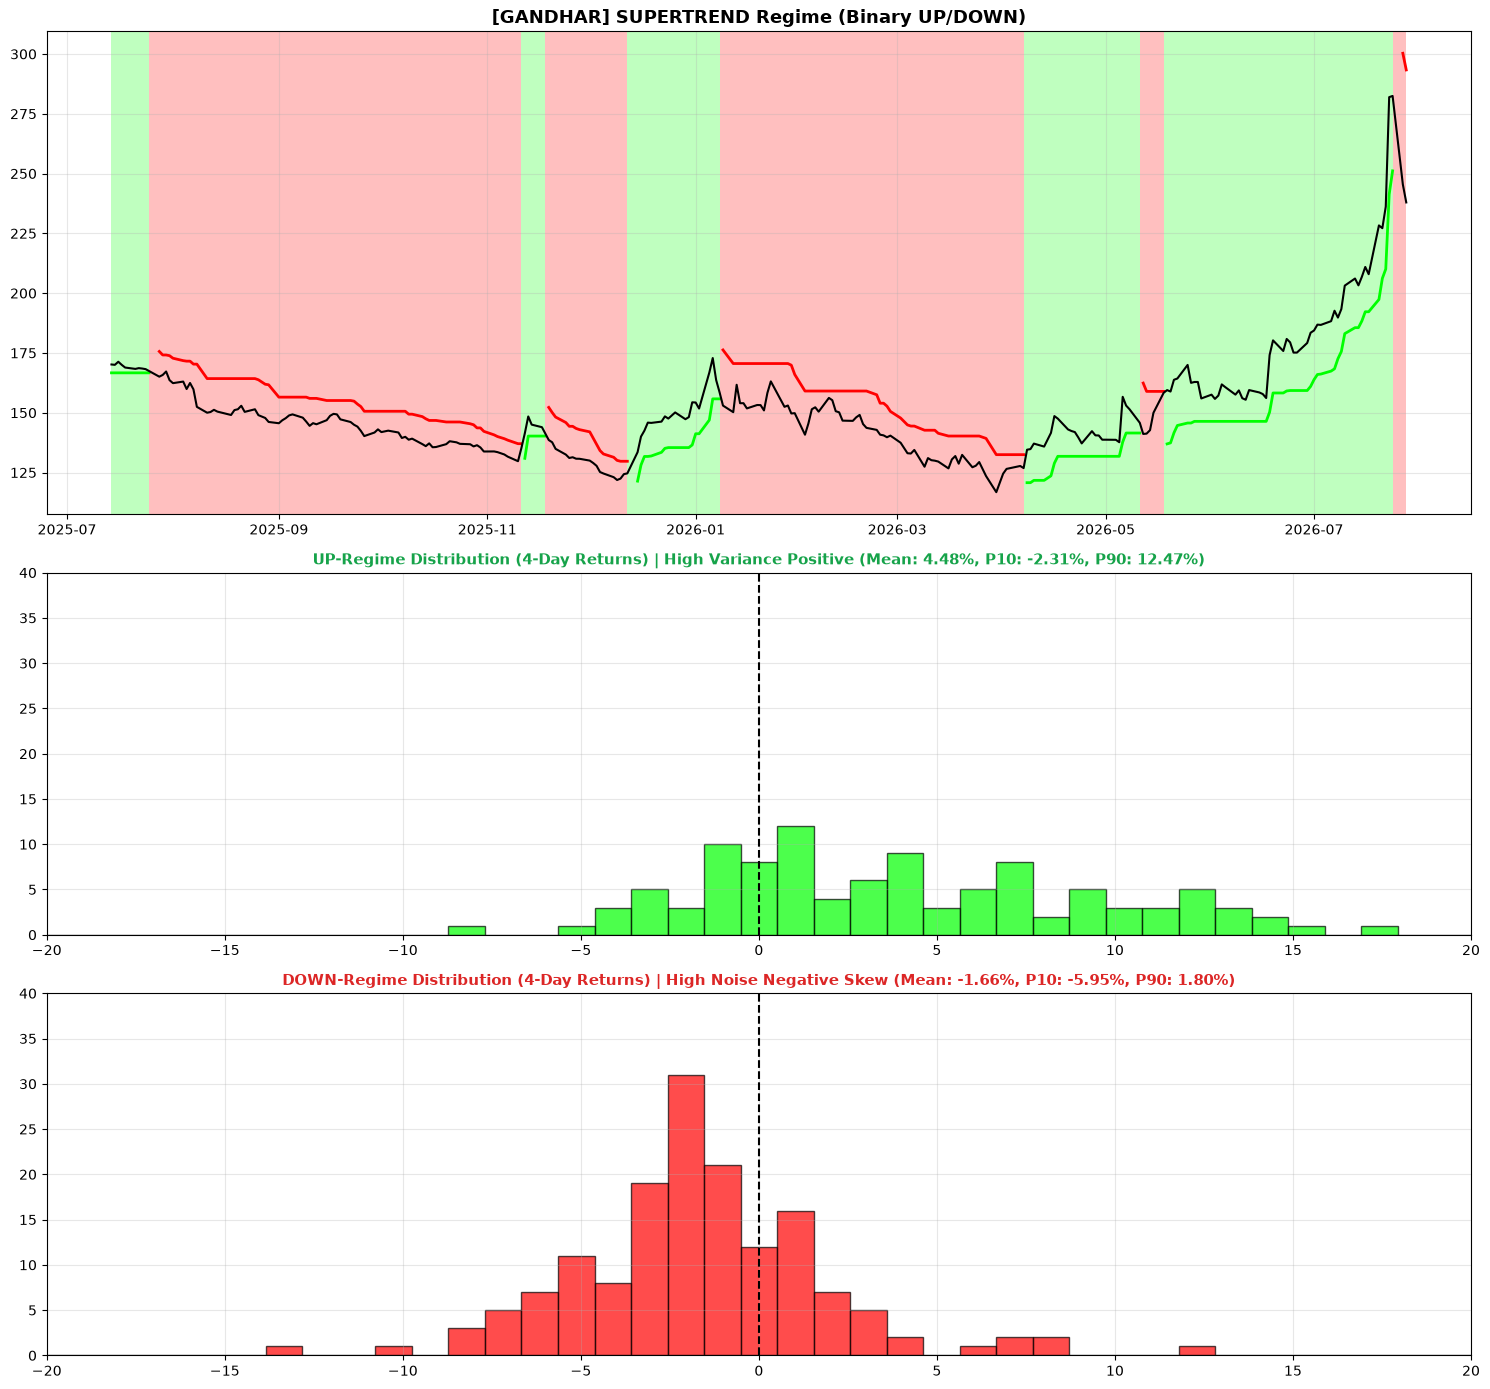

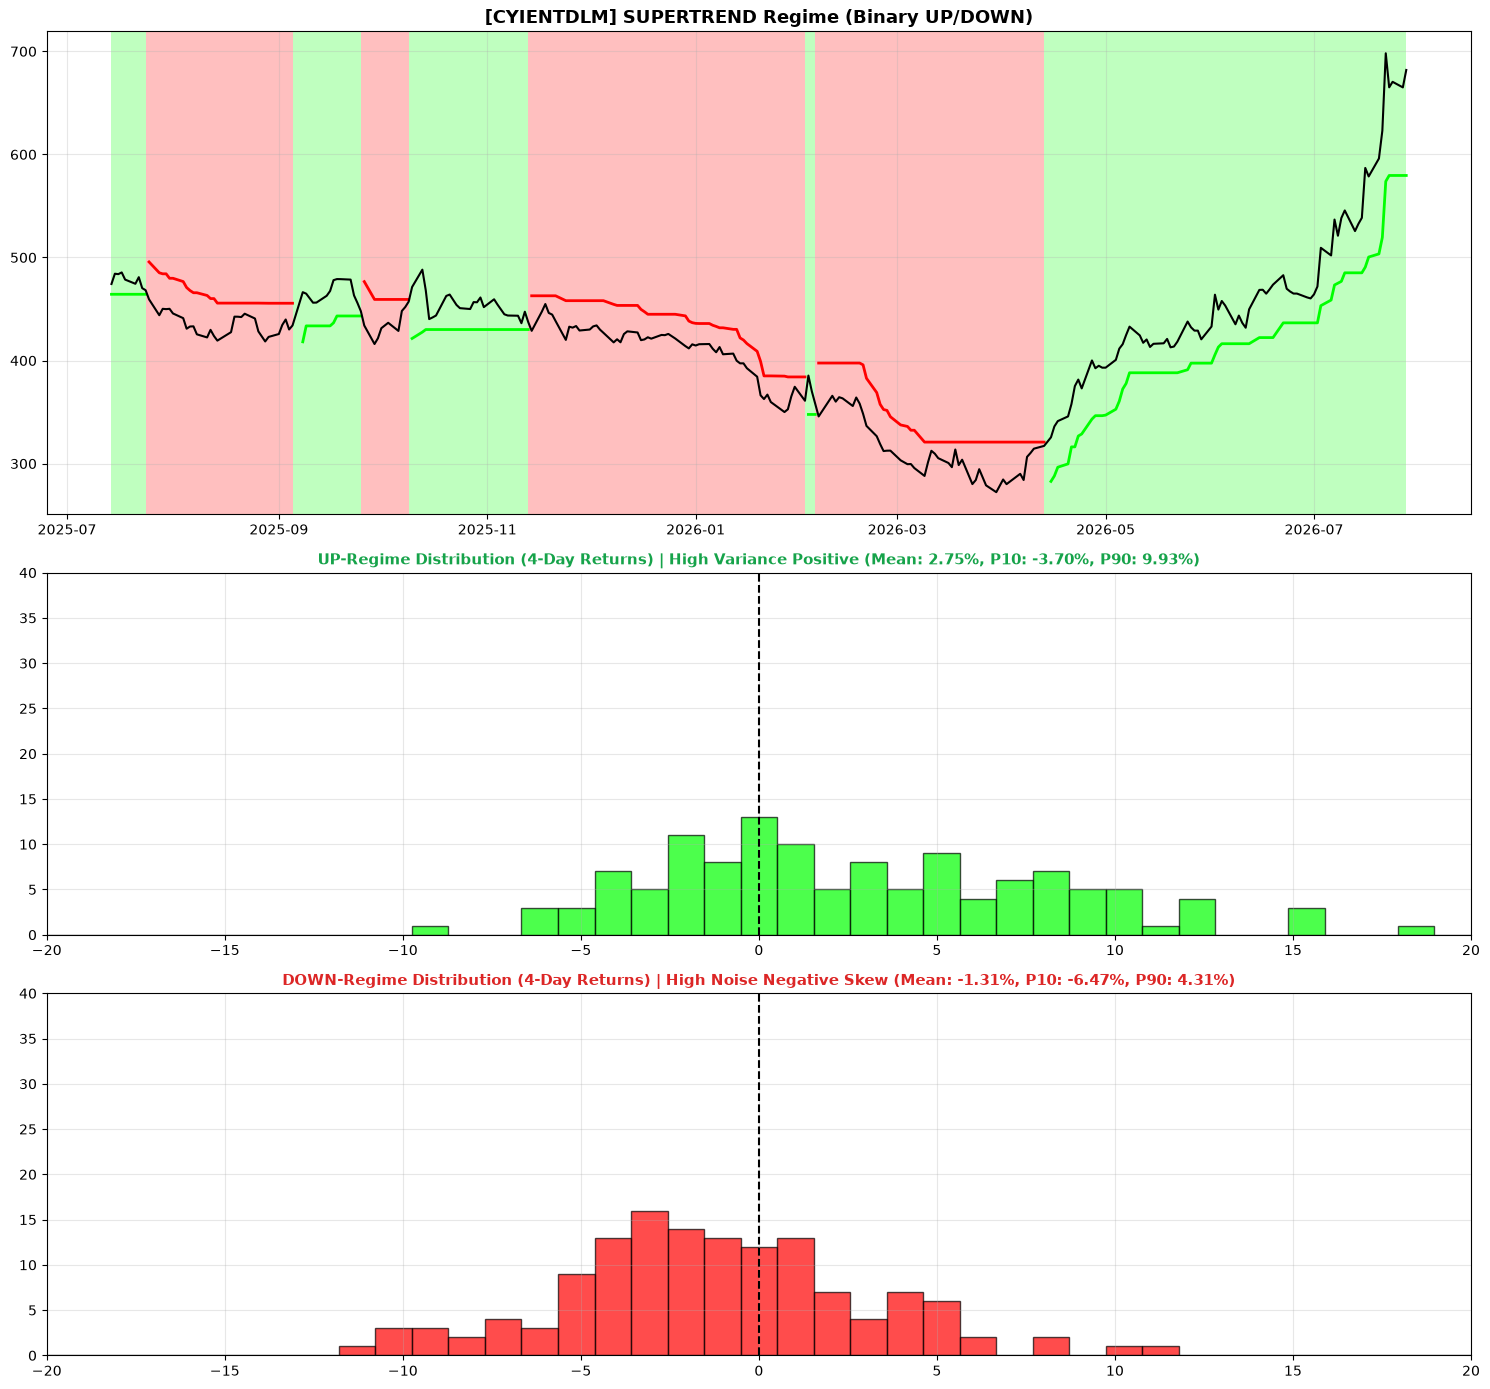

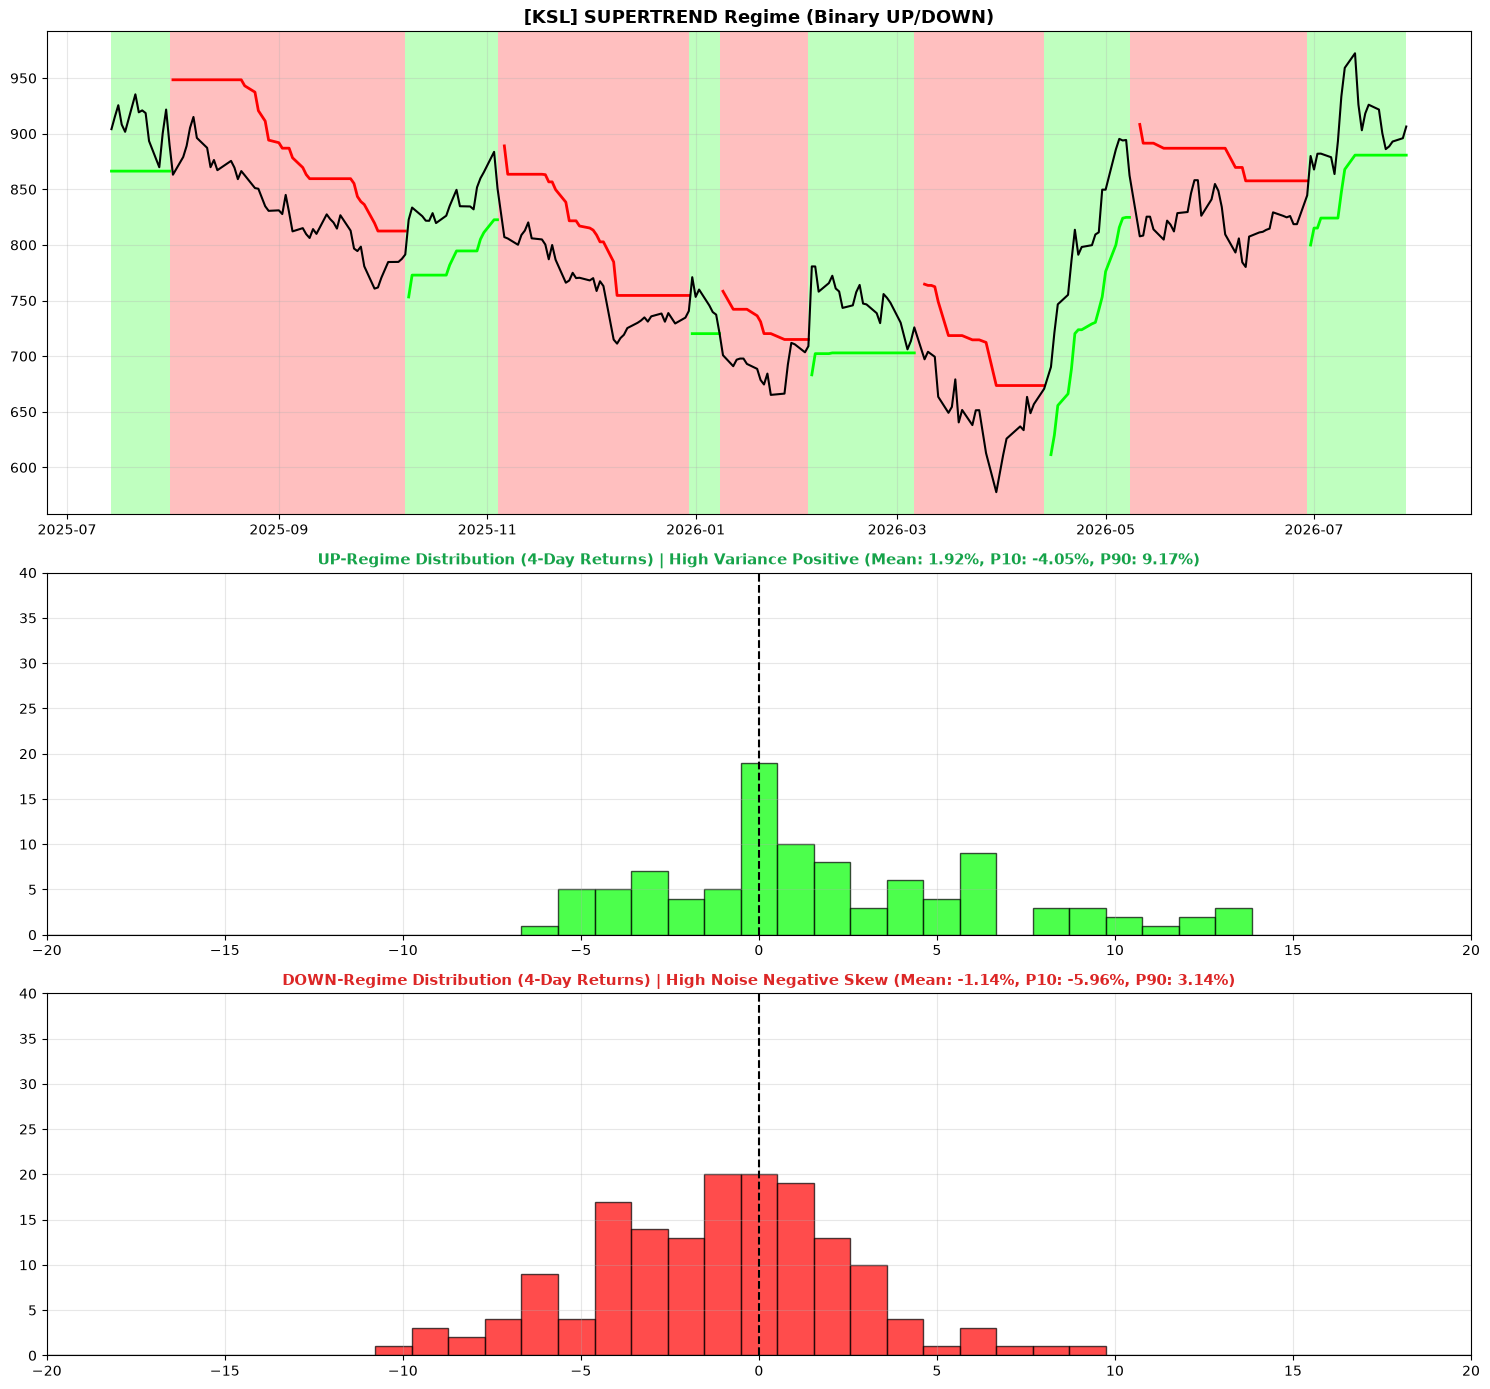

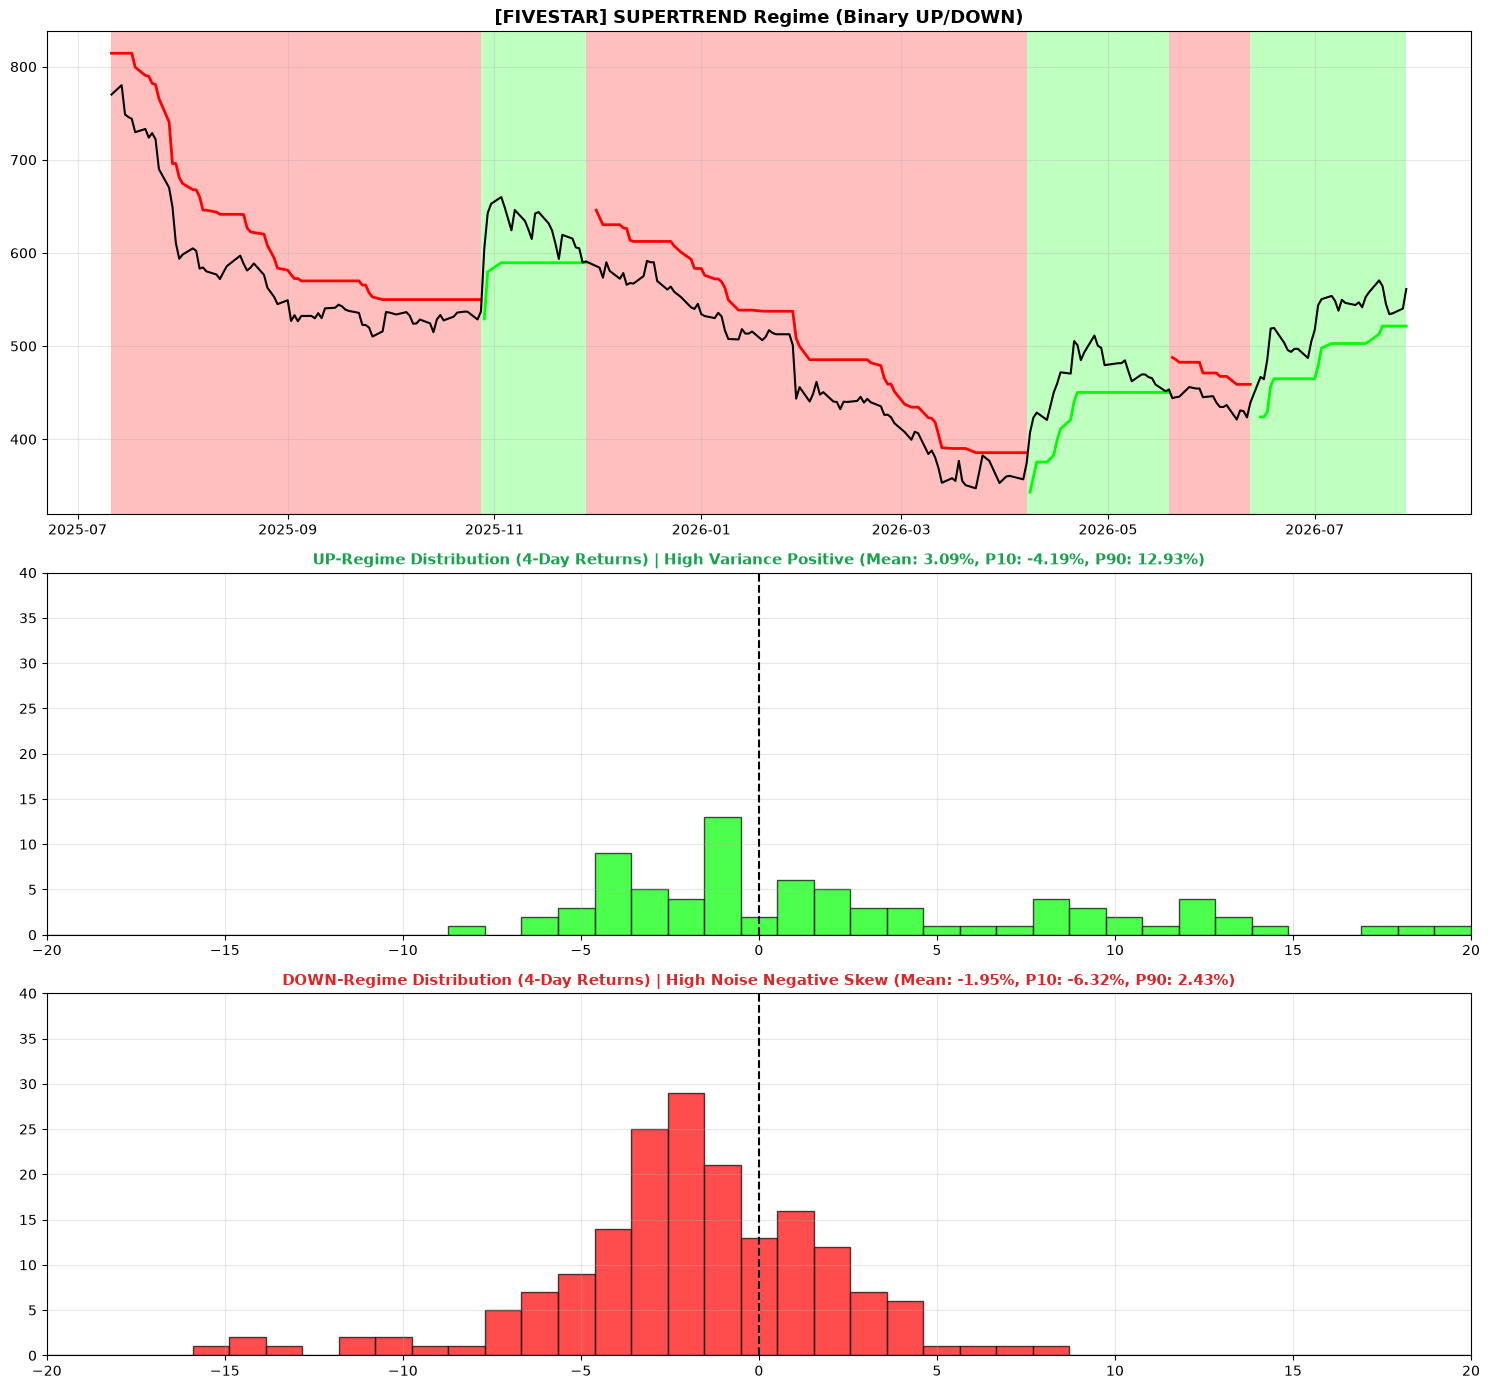

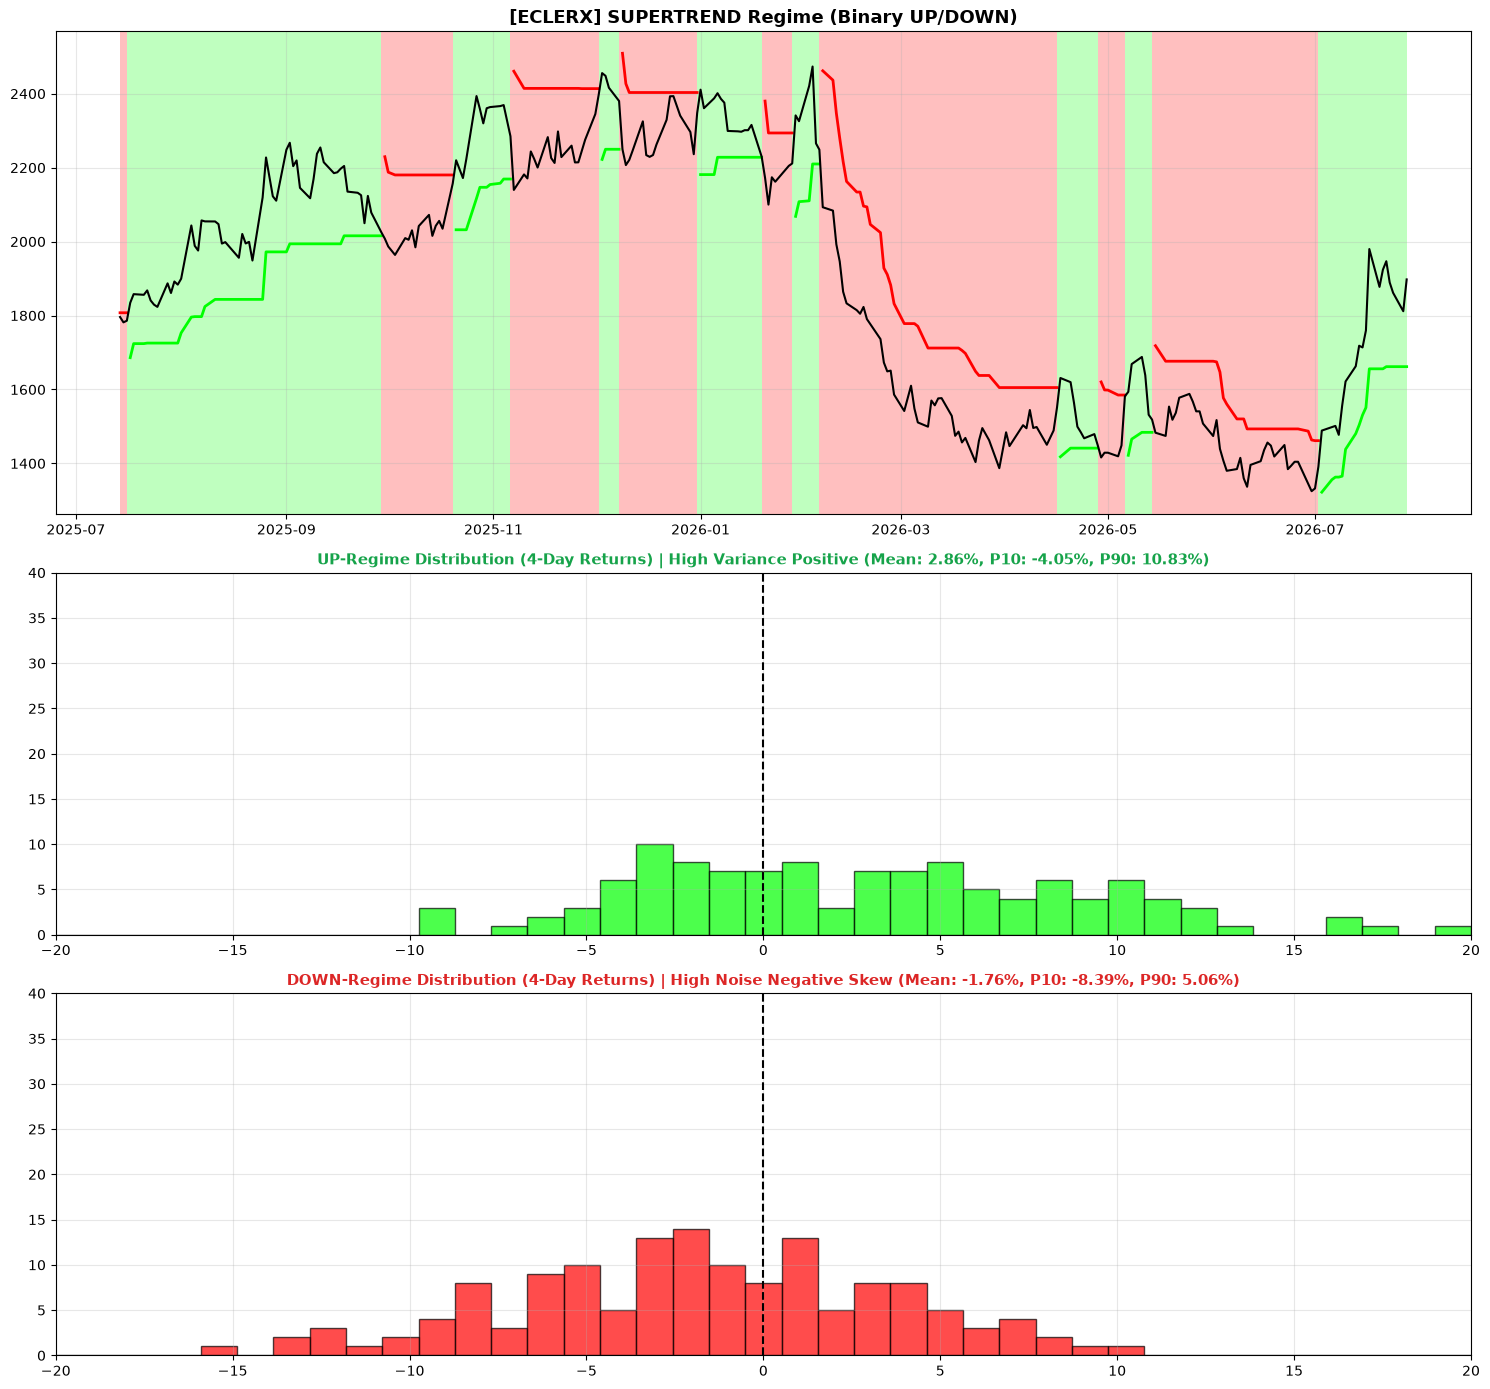

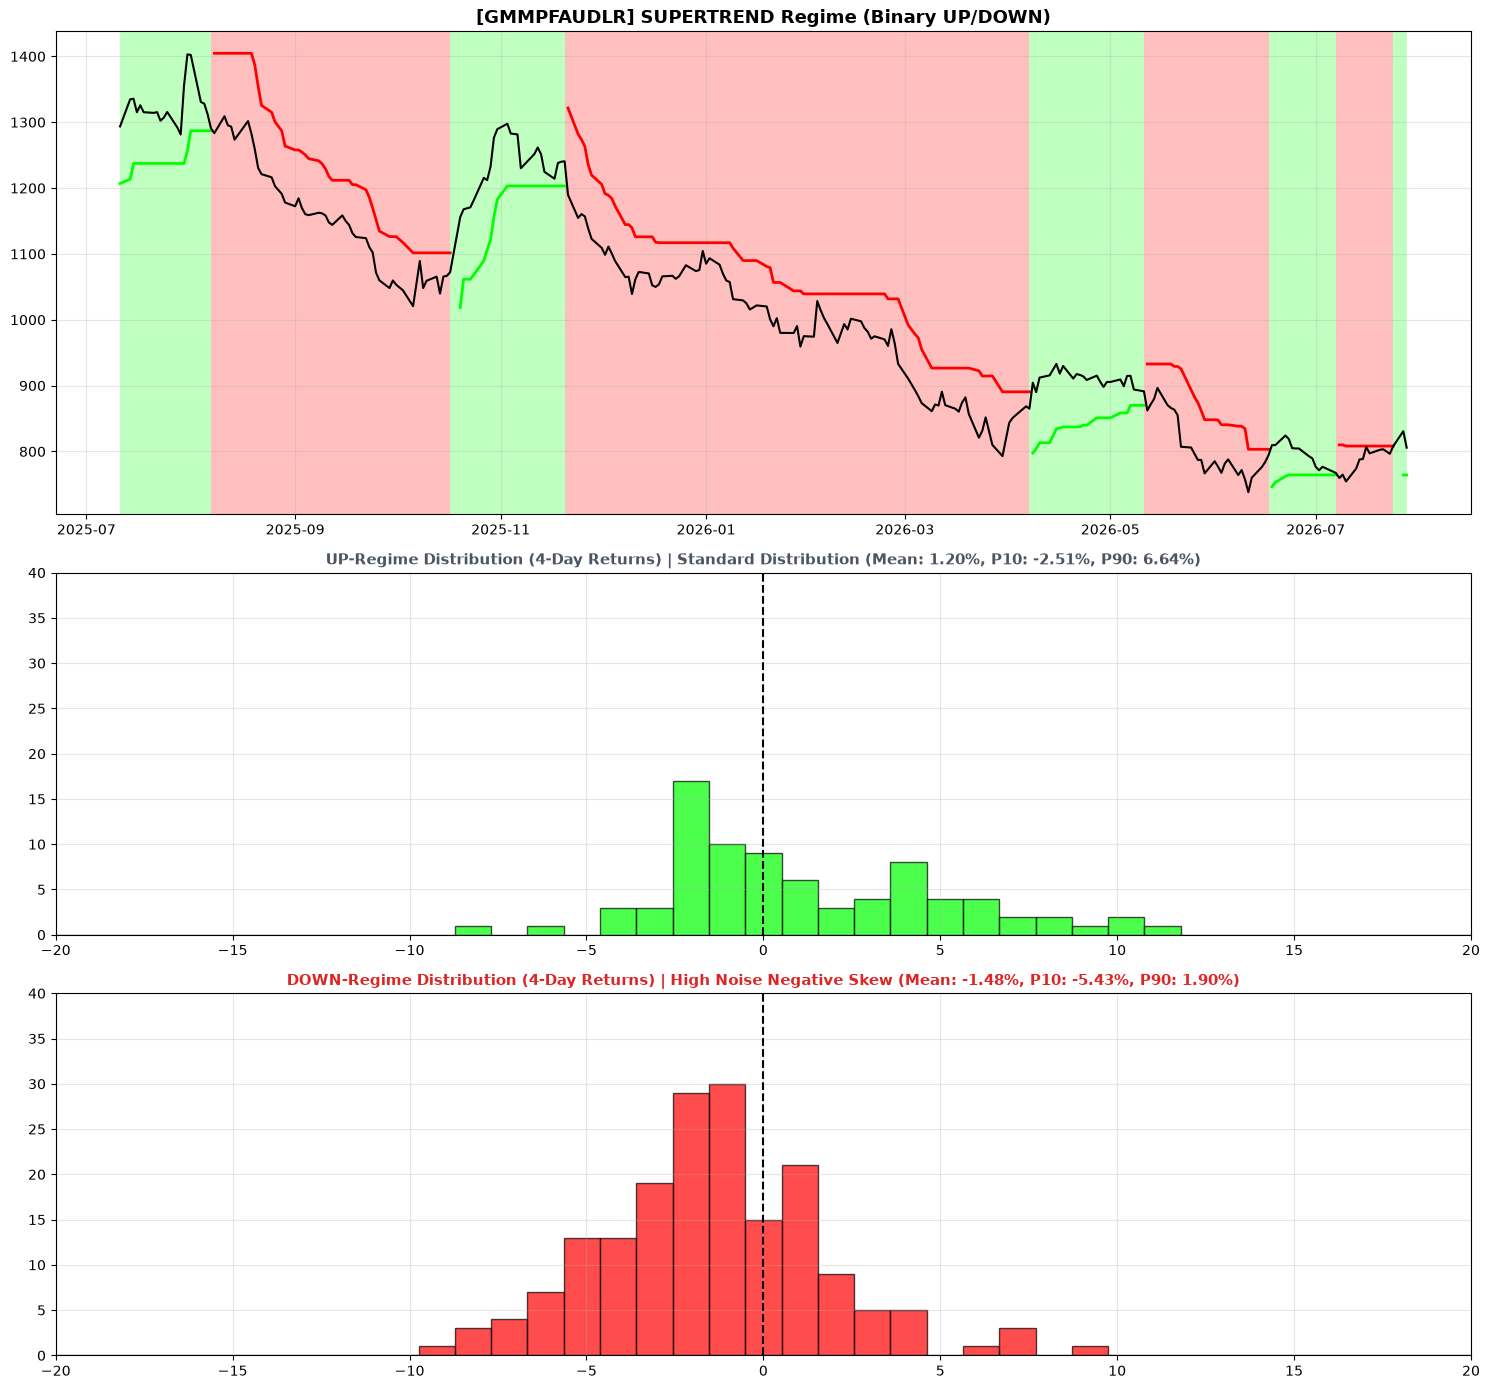

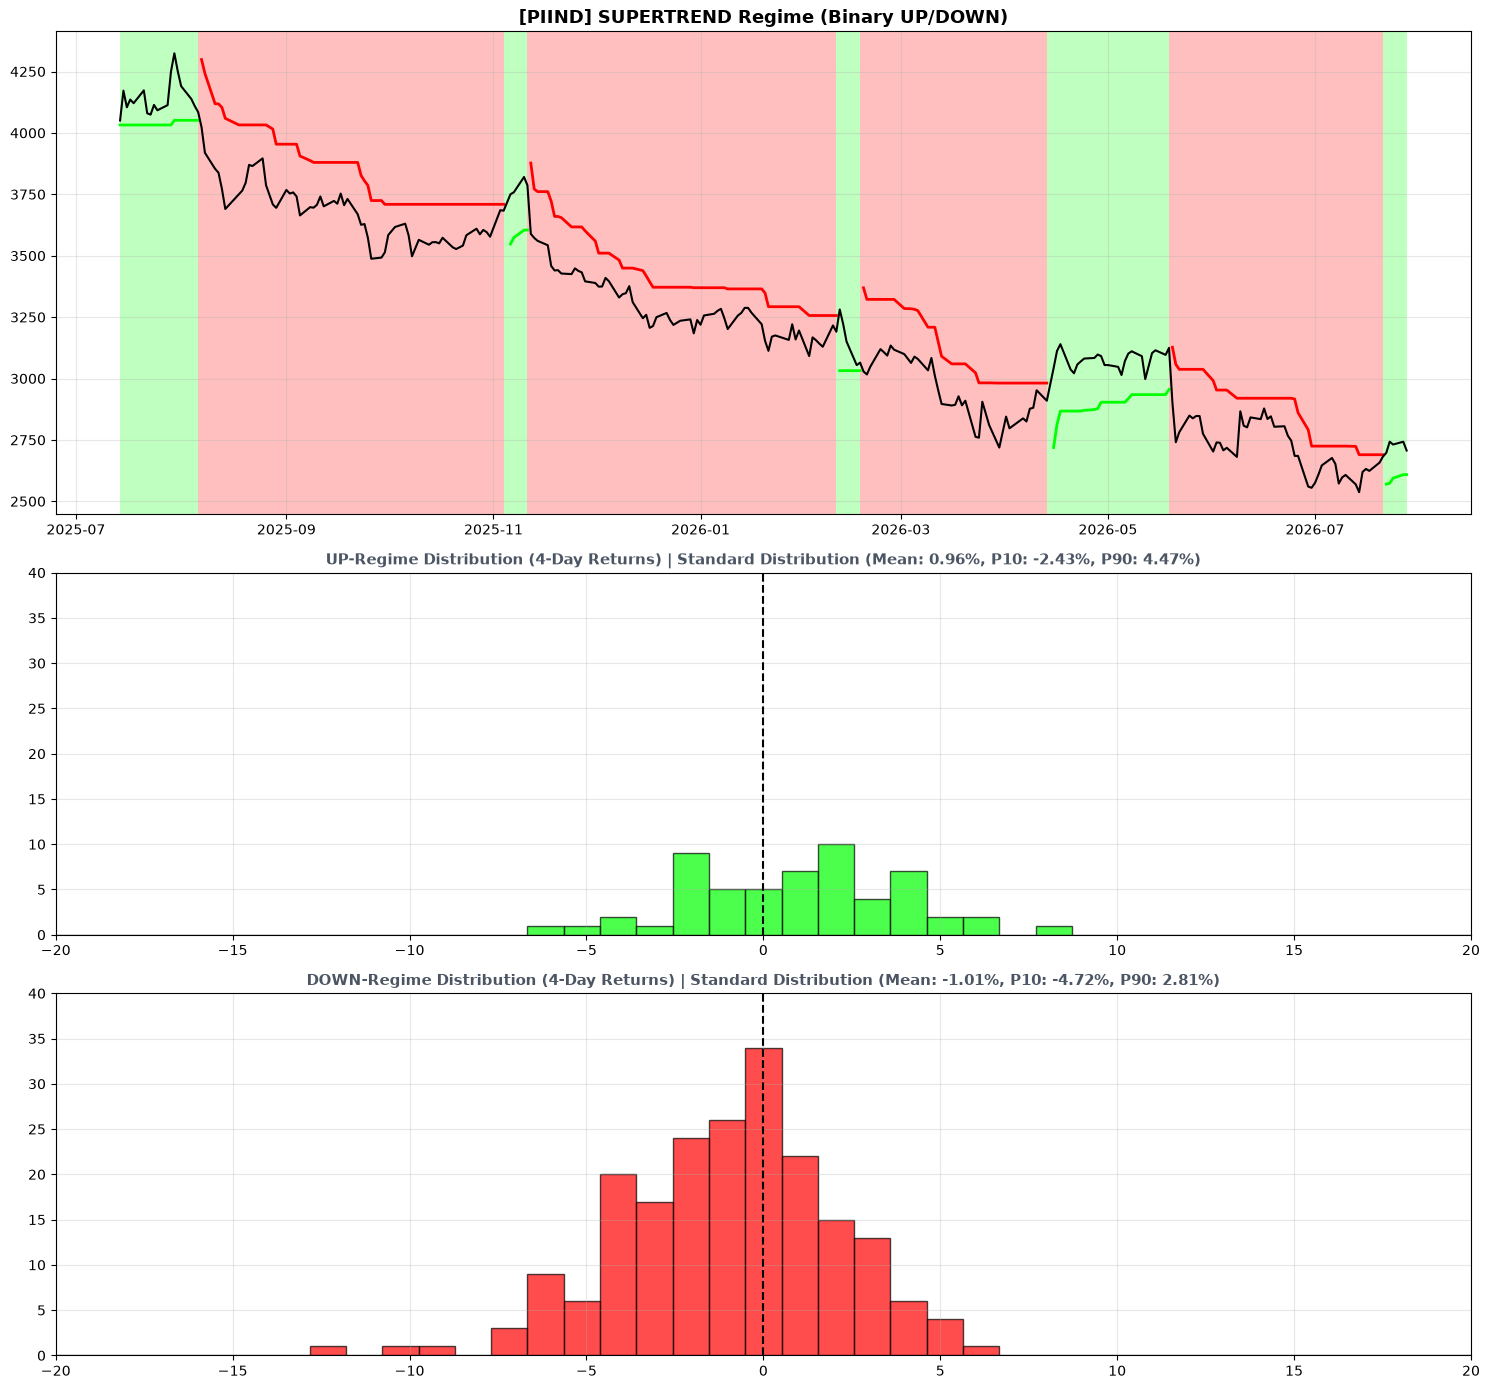

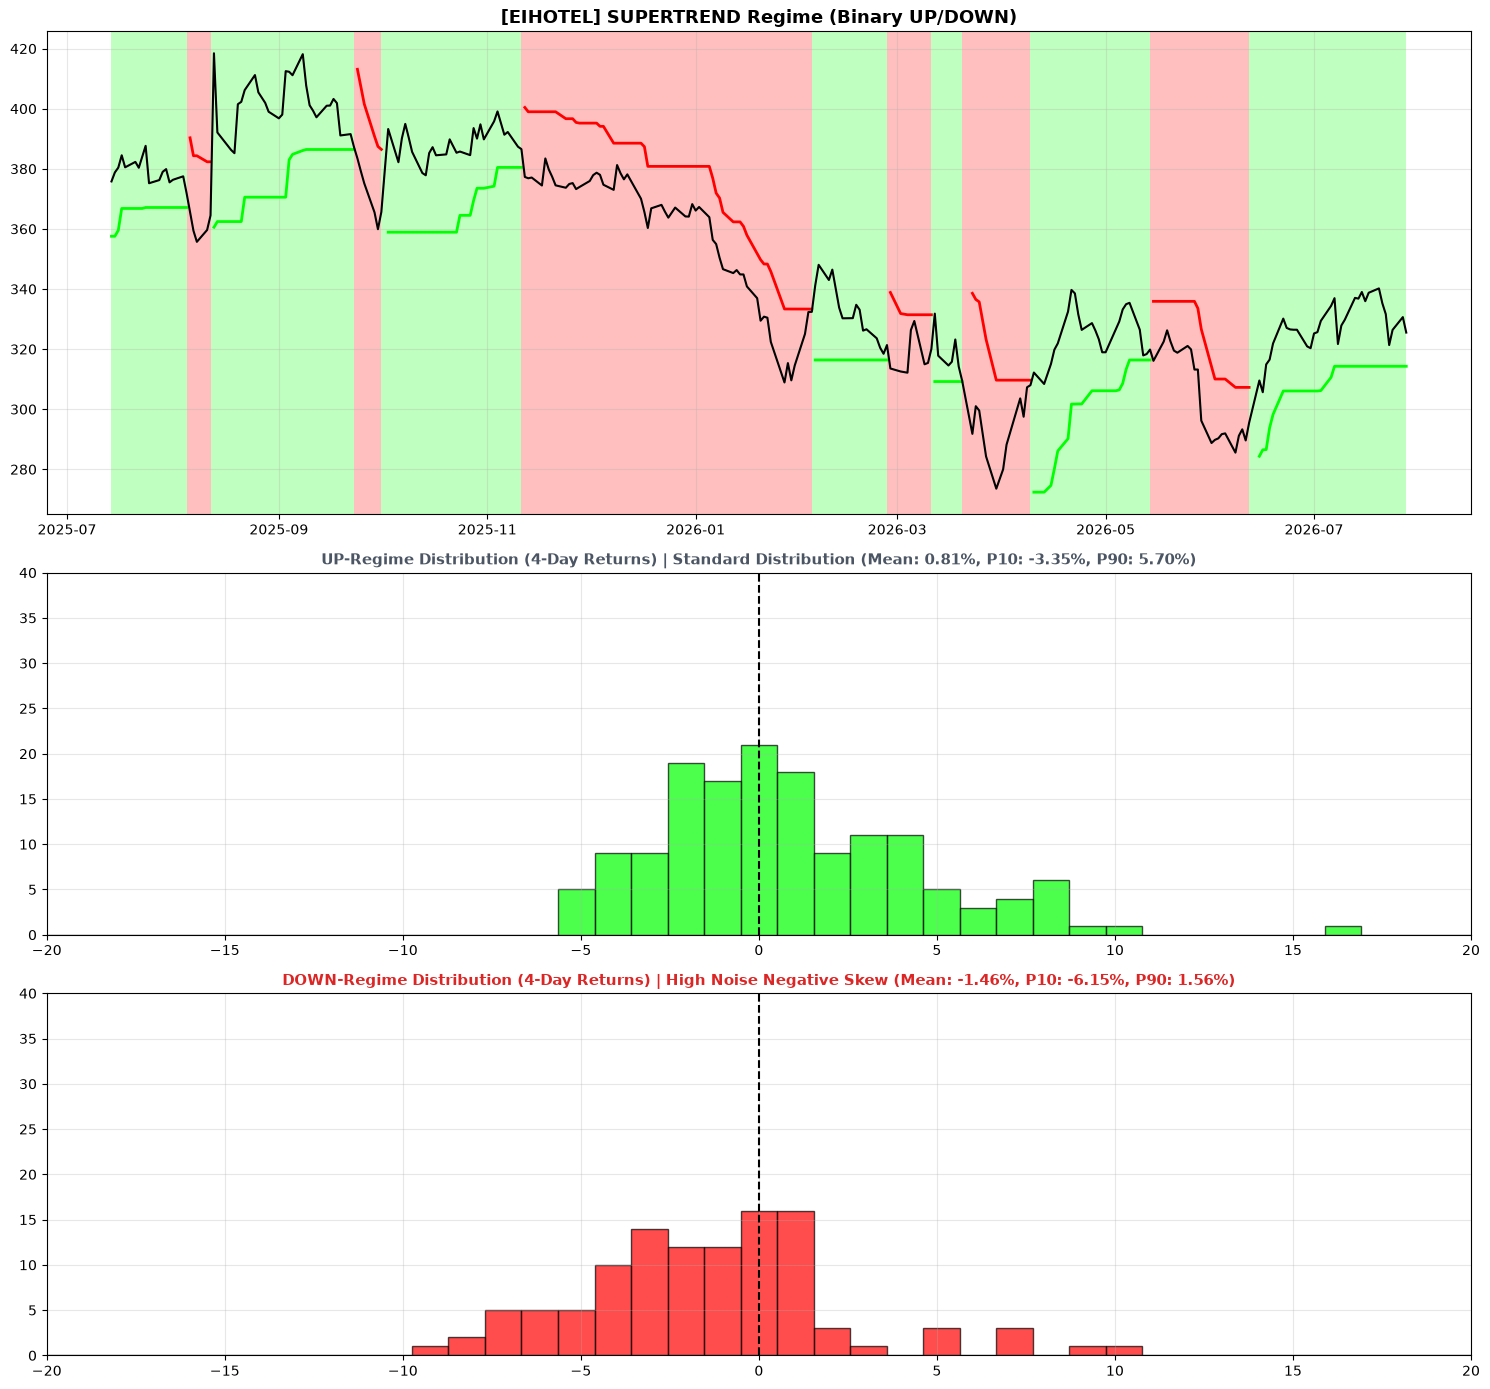

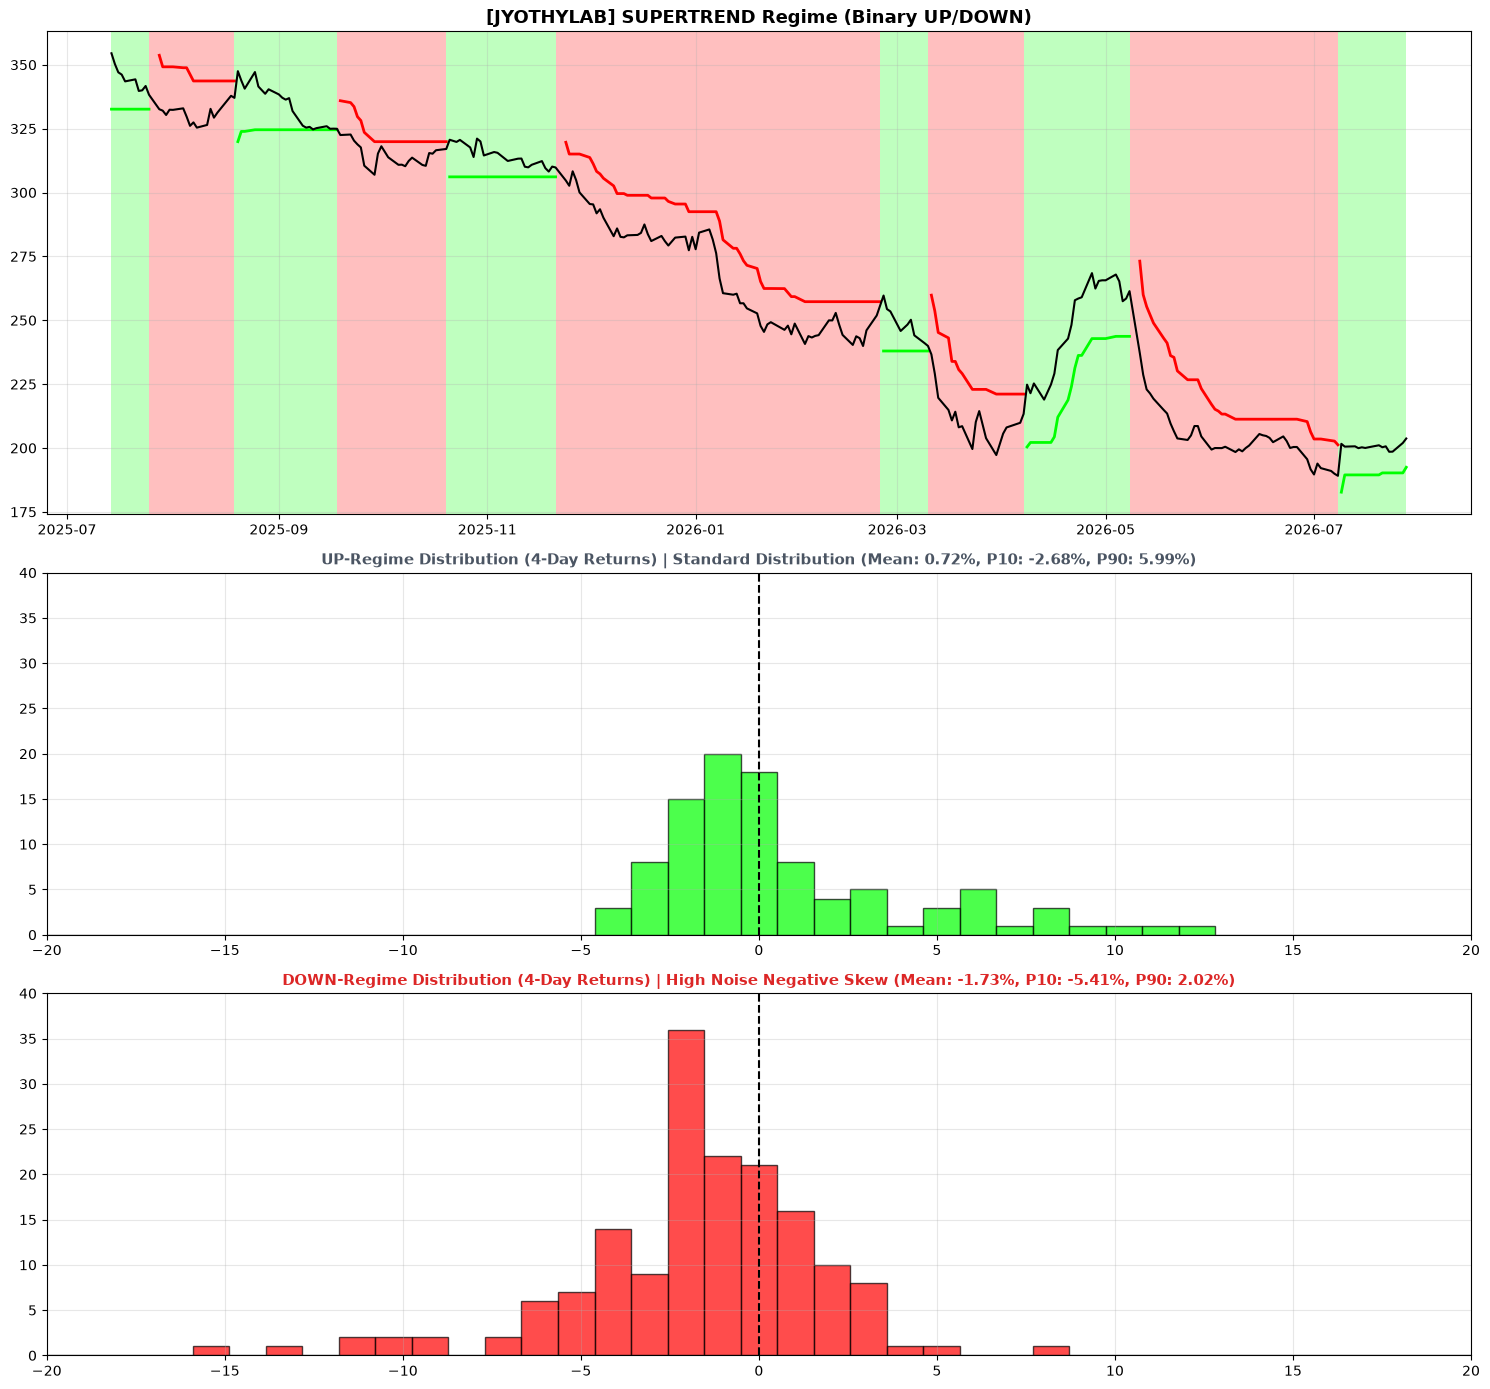

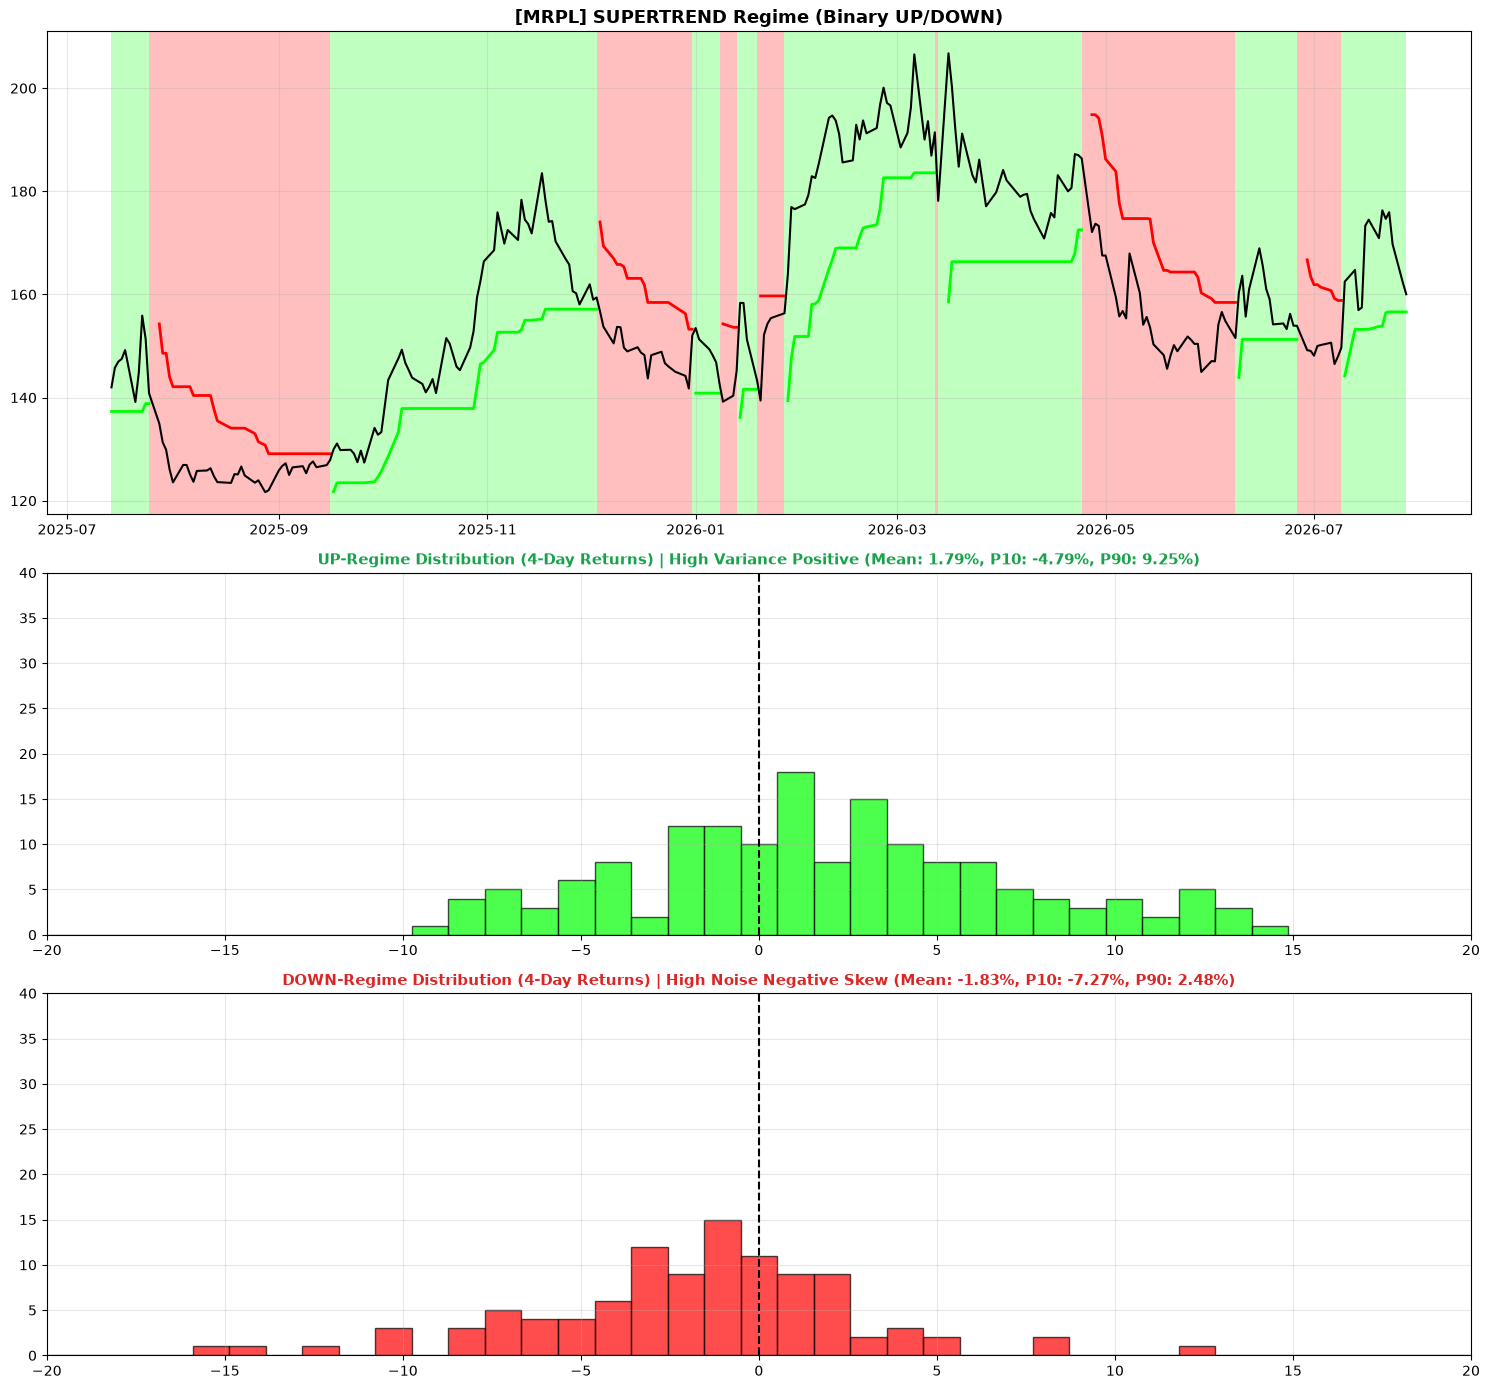

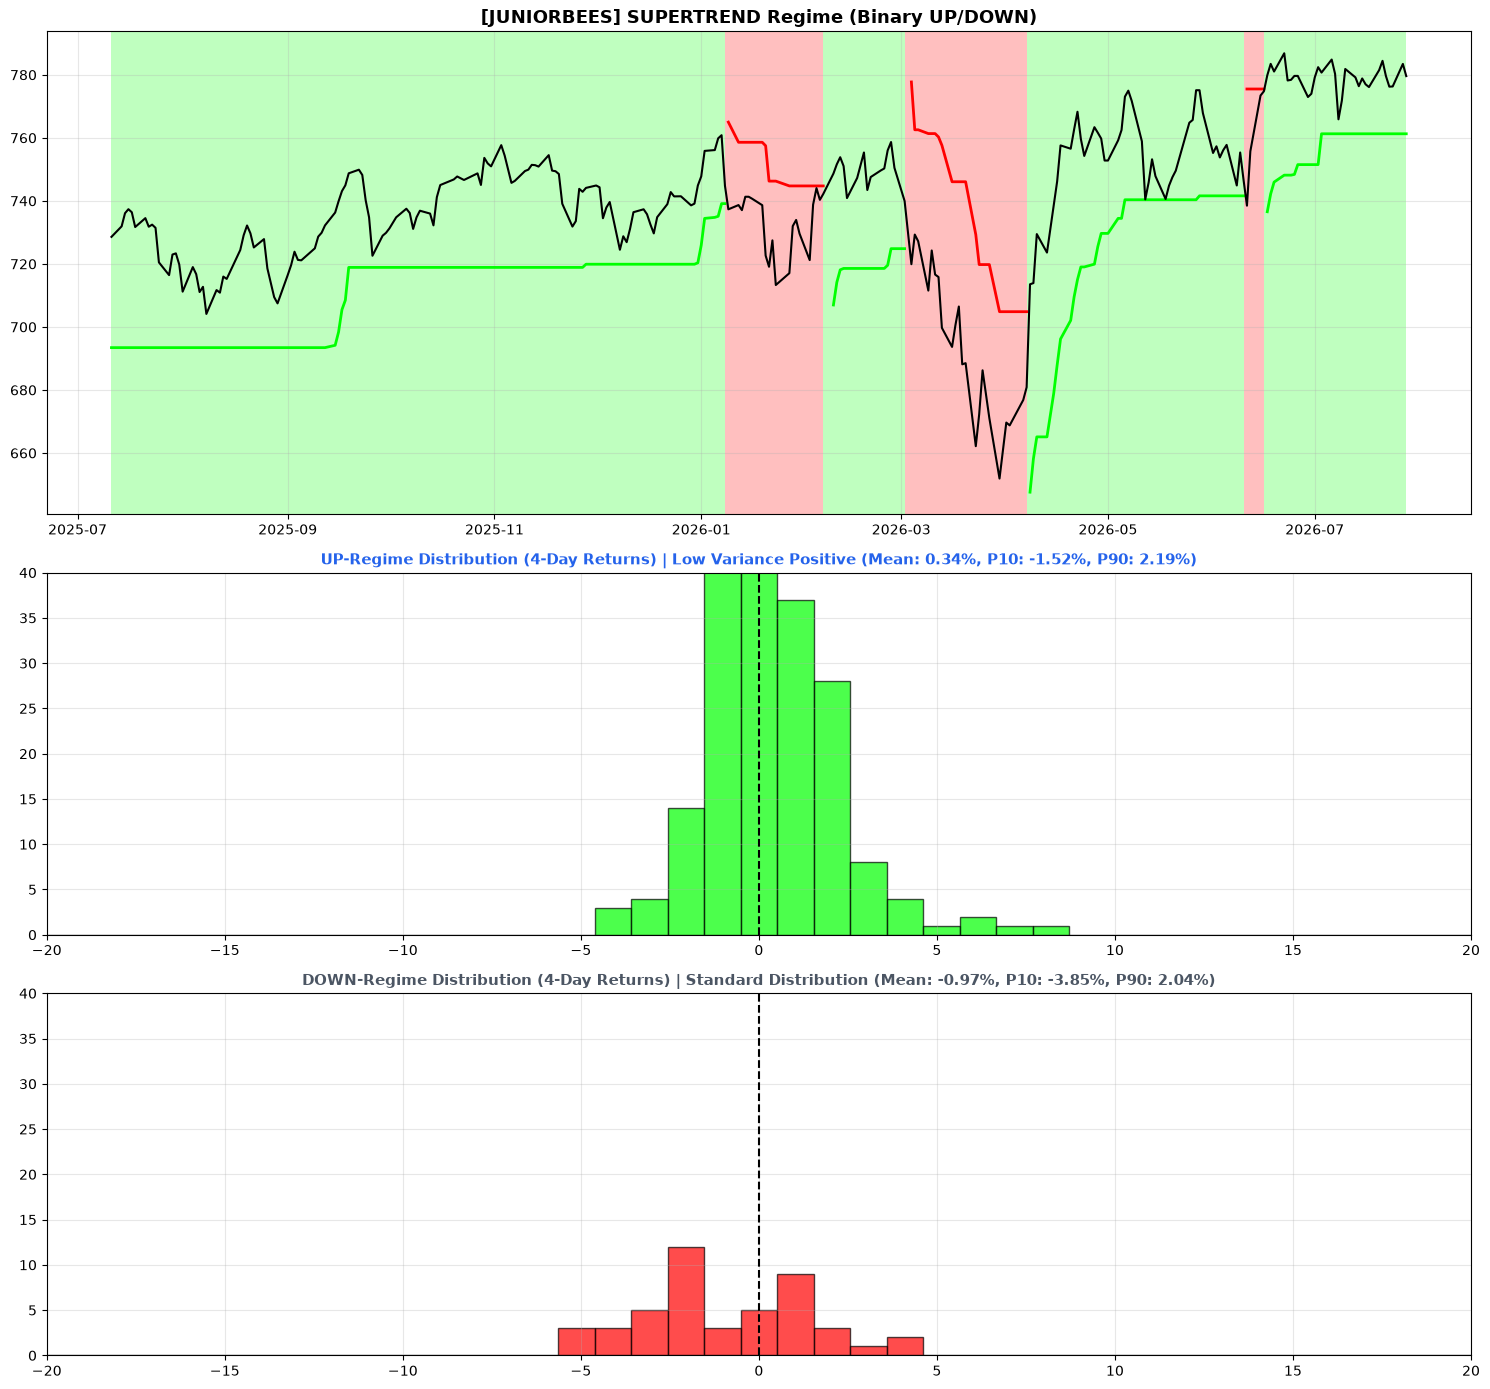

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, random, glob

# 1. CONFIGURATION
SEED = 42
TARGET_DURATION = 13

ROLLING_WINDOW = max(1, int(TARGET_DURATION / 3))     # 4 Days (1/3 of Target)
REGIME_LOOKBACK = TARGET_DURATION * 2                 # 26 Days
PR_BASELINE = TARGET_DURATION * 15                    # 195 Days
LOOKBACK_BLOCK = TARGET_DURATION * 20                 # 260 Days

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
random.seed(SEED)
random.shuffle(all_files)
selected_files = all_files[:20]

os.makedirs('../output', exist_ok=True)

# --- SUPERTREND (ATR) ---
def calc_supertrend(df, period=REGIME_LOOKBACK, multiplier=3.0):
    high = df['High']
    low = df['Low']
    close = df['Close']
    
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(period).mean()
    
    hl2 = (high + low) / 2
    basic_ub = hl2 + (multiplier * atr)
    basic_lb = hl2 - (multiplier * atr)
    
    final_ub = np.zeros(len(df))
    final_lb = np.zeros(len(df))
    trend = np.ones(len(df))
    
    for i in range(period, len(df)):
        if basic_ub.iloc[i] < final_ub[i-1] or close.iloc[i-1] > final_ub[i-1]:
            final_ub[i] = basic_ub.iloc[i]
        else:
            final_ub[i] = final_ub[i-1]
            
        if basic_lb.iloc[i] > final_lb[i-1] or close.iloc[i-1] < final_lb[i-1]:
            final_lb[i] = basic_lb.iloc[i]
        else:
            final_lb[i] = final_lb[i-1]
            
        if close.iloc[i] > final_ub[i-1]:
            trend[i] = 1
        elif close.iloc[i] < final_lb[i-1]:
            trend[i] = -1
        else:
            trend[i] = trend[i-1]
            
    final_ub = pd.Series(final_ub, index=df.index).replace(0, np.nan)
    final_lb = pd.Series(final_lb, index=df.index).replace(0, np.nan)
    trend = pd.Series(trend, index=df.index)
    return trend, final_ub, final_lb

# 2. STATISTICAL CLASSIFICATION ENGINE
def classify_distribution(returns, target_days):
    if len(returns) < 10:
        return "INSUFFICIENT DATA", '#4b5563'
        
    p10 = np.percentile(returns, 10)
    p90 = np.percentile(returns, 90)
    mean = returns.mean()
    
    # Pure statistical descriptions (No invented terminology)
    if p90 >= 8 and mean > 1.5:
        return f"High Variance Positive (Mean: {mean:.2f}%, P10: {p10:.2f}%, P90: {p90:.2f}%)", '#16a34a'
    elif p10 <= -5 and mean <= 0:
        return f"High Noise Negative Skew (Mean: {mean:.2f}%, P10: {p10:.2f}%, P90: {p90:.2f}%)", '#dc2626'
    elif p90 < 5 and p10 > -2 and mean > 0:
        return f"Low Variance Positive (Mean: {mean:.2f}%, P10: {p10:.2f}%, P90: {p90:.2f}%)", '#2563eb'
    else:
        return f"Standard Distribution (Mean: {mean:.2f}%, P10: {p10:.2f}%, P90: {p90:.2f}%)", '#4b5563'

# 3. EXTRACT AND PLOT
for file_path in selected_files:
    symbol = os.path.basename(file_path).split('.')[0]
    df = pd.read_csv(file_path)
    if 'High' not in df.columns: continue
    
    df['Date'] = pd.to_datetime(df['Date'])
    df['Rolling_Ret'] = df['Close'].pct_change(periods=ROLLING_WINDOW) * 100
    
    df['ST_Trend'], df['ST_UB'], df['ST_LB'] = calc_supertrend(df, period=14, multiplier=2.5)
    df['Regime'] = np.where(df['ST_Trend'] == 1, 'UP', 'DOWN')
    
    if len(df) < (LOOKBACK_BLOCK + PR_BASELINE): continue
    block = df.iloc[-LOOKBACK_BLOCK:].copy()
    
    up_ret = block[block['Regime'] == 'UP']['Rolling_Ret'].dropna()
    dn_ret = block[block['Regime'] == 'DOWN']['Rolling_Ret'].dropna()
    
    fig, axes = plt.subplots(3, 1, figsize=(15, 14), gridspec_kw={'height_ratios': [2, 1.5, 1.5]})
    
    # PANEL 1: PRICE & REGIME
    axes[0].plot(block['Date'], block['Close'], color='black', linewidth=1.5, zorder=3)
    axes[0].plot(block['Date'], np.where(block['ST_Trend']==1, block['ST_LB'], np.nan), color='lime', linewidth=2)
    axes[0].plot(block['Date'], np.where(block['ST_Trend']==-1, block['ST_UB'], np.nan), color='red', linewidth=2)
    
    for i in range(1, len(block)):
        r = block['Regime'].iloc[i]
        c = 'lime' if r == 'UP' else 'red'
        axes[0].axvspan(block['Date'].iloc[i-1], block['Date'].iloc[i], color=c, alpha=0.25, lw=0)
        
    axes[0].set_title(f"[{symbol}] SUPERTREND Regime (Binary UP/DOWN)", fontsize=13, weight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # PANEL 2: UP REGIME DISTRIBUTION
    prof_up, color_up = classify_distribution(up_ret, ROLLING_WINDOW)
    axes[1].hist(up_ret, bins=np.linspace(-20, 20, 40), color='lime', edgecolor='black', alpha=0.7)
    axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
    axes[1].set_title(f"UP-Regime Distribution ({ROLLING_WINDOW}-Day Returns) | {prof_up}", fontsize=11, weight='bold', color=color_up)
    axes[1].set_xlim(-20, 20)
    axes[1].set_ylim(0, 40)
    axes[1].grid(True, alpha=0.3)
    
    # PANEL 3: DOWN REGIME DISTRIBUTION
    prof_dn, color_dn = classify_distribution(dn_ret, ROLLING_WINDOW)
    axes[2].hist(dn_ret, bins=np.linspace(-20, 20, 40), color='red', edgecolor='black', alpha=0.7)
    axes[2].axvline(0, color='black', linestyle='--', linewidth=1.5)
    axes[2].set_title(f"DOWN-Regime Distribution ({ROLLING_WINDOW}-Day Returns) | {prof_dn}", fontsize=11, weight='bold', color=color_dn)
    axes[2].set_xlim(-20, 20)
    axes[2].set_ylim(0, 40)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    filename = f"../output/final_regime_{symbol}.jpg"
    plt.savefig(filename, format='jpeg', bbox_inches='tight')
    plt.show()
